# **Facial Emotion Detection**

## **Problem Definition**

### Why it’s important
Facial emotion recognition is important because it enables technology to respond to people in more human-centered, context-aware ways. By interpreting affective cues like happiness, confusion, stress, or fatigue, systems can adapt interfaces, timing, and interventions to improve usability, safety, and outcomes. This matters in settings where emotional state influences performance or well-being—such as learning, therapy, and driving—where timely, objective, and scalable signals can complement limited human attention. FER also supports accessibility by giving voice to nonverbal cues for individuals with communication challenges, and it offers consistent measurements that reduce the noise and cost of manual observation.

Beyond interaction quality, FER unlocks data-driven insights about engagement and sentiment across products and services, informing design, operations, and support. When implemented with strong privacy protections, fairness controls, and transparent governance, it can elevate customer experience in contact centers, personalize training in education, and augment clinical judgment in telehealth without storing sensitive visuals. In short, FER bridges the gap between intent and interface, translating subtle facial dynamics into actionable feedback that makes digital systems safer, more empathetic, and more effective.
#### Who benefits (selected fields)
+ Healthcare and mental health
+ Education and training
+ Automotive and transportation
+ Customer service, CX, and retail
+ Entertainment, gaming, and AR/VR
+ HR, interviewing, and workforce analytics
+ Social robotics and assistive tech
+ Marketing and user research
+ Security and public safety (with strong governance)
+ Smart homes and IoT
#### Major applications
+ Telehealth triage and remote therapy support
+ Classroom and e-learning engagement analytics
+ Driver monitoring (drowsiness, distraction)
+ Contact centers: agent assistance, sentiment escalation
+ In-store analytics and digital signage responsiveness
+ Adaptive UX for apps, games, and XR
+ Interview coaching and soft-skills training
+ Companion robots and eldercare monitoring
+ Usability testing and product research
+ On-device affect-aware assistants
#### TAM and who could leverage it
With vertical solutions (auto safety, telehealth analytics, CCaaS add-ons), a broader affect-aware software market plausibly reaches $10–25B+/yr over the next decade, depending on regulation, on-device adoption, and privacy norms.
Note: success hinges on governance, accuracy across demographics, privacy-preserving deployment (on-device), and societal acceptance.

### The objectives: What is the intended goal?
The goal of this project is to develop a facial emotion detection model that can accurately classify images with facial expressions into five categories: happy, sad, surprise, and neutral. This model will be trained on a dataset of facial images labeled with corresponding emotions, and it will be evaluated using various metrics to assess its performance. The ultimate aim is to create a robust and reliable system that can be integrated into various applications and devices to enhance user experience and provide valuable insights into human emotions.  While beyond the scope of this project, it would be interesting to see how the models produced could be extended to processes video data, and potentially even to real-time emotion detection in video streams.

#### Key Questions
For this project, we need to assess all the factors that will be used to create a solution:
+ Do we have good data?
    + Do we have sufficient data for training and validation?
    + Do we have diverse, consented, representative datasets covering age, gender, skin tone, culture, occlusions (masks, glasses), lighting, and devices?
    + Do we have good labels?  Is there cultural bias in the labels, and are the labels accurate and consistent across the dataset?
+ Modeling
    + We have several model architectures to choose from, as well as existing models that can be extended or fine-tuned.
    + How do we choose the best architecture?
    + How should hyper-parameters be tuned?
+ Evaluation
    + What criteria should be used to make decisions about candidate viability?
    + We can use accuracy metrics, including precision, recall, F1 score, and confusion matrices.
        + What other objective or performance metrics can be used?
            + Efficiency, scalability?
            + Model size?
            + Training expense or time?

### The problem formulation:
What are we using data science to solve?  We seek to develop machine learning models that can recognize emotional state from a picture of a face.  Along the way, proven data science practices will guide every step.  We will:
+ Use exploratory data analysis to understand the dataset, detect issues and resolve them.
+ Leverage multi-layered neural networks to process the data, and softmax algorithms to convert the output into a statistical classification.
+ Explore the differences in accuracy between ANNs and CNNs for image processing
+ Explore various hyper-parameter settings to find the optimal configuration for a given architecture
+ Use the accuracy scores as the primary means of comparison between models, but other factors may play a role in the final model selection
+ Observations and analysis will be provided at each step, backed by data

And once a model has been chosen, the reasoning and data backing this decision will be provided.


## **About the dataset**

The data set consists of 3 folders, i.e., 'test', 'train', and 'validation'. 
Each of these folders has four subfolders:

**‘happy’**: Images of people who have happy facial expressions.<br>
**‘sad’**: Images of people with sad or upset facial expressions.<br>
**‘surprise’**: Images of people who have shocked or surprised facial expressions.<br>
**‘neutral’**: Images of people showing no prominent emotion in their facial expression at all.<br>


## Importing the Libraries & Utility Functions

In [1]:
from opt_einsum.backends import evaluate_constants
from sklearn.metrics import precision_recall_fscore_support
import math
import cv2
import hashlib
import random
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import os
from sklearn.model_selection import train_test_split
from keras.src.applications.vgg16 import VGG16
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd
import seaborn as sns
from keras import optimizers

import tensorflow as tf
tf.get_logger().setLevel("ERROR")
import tensorflow.keras.applications as ap
from tensorflow.python.keras import backend
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.layers import Dense, Input, Dropout, Flatten, Conv2D, BatchNormalization, MaxPooling2D, LeakyReLU
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.optimizers import Adam

def fs_to_dataframe(root_dir):
    """
    Walk a directory tree from root_dir and return a DataFrame with:
      - file_path: absolute path to each file
      - emotion: immediate parent directory name (label)
    """
    rows = []
    for current_root, _, files in os.walk(root_dir):
        emotion = os.path.basename(current_root)
        for fname in files:
            fpath = os.path.join(current_root, fname)
            if os.path.isfile(fpath):
                rows.append({
                    "filename": os.path.abspath(fpath),
                    "label": emotion,
                })
    return pd.DataFrame(rows, columns=["filename", "label"])

def head_images(df, label, n=9, target_size=(48, 48)):
    subset = df[df["label"] == label].head(n)
    if subset.empty:
        print(f"No images found for label: {label}")
        return
    plt.figure(figsize=(8, 8))
    for i, (_, row) in enumerate(subset.iterrows(), start=1):
        plt.subplot(3, 3, i)
        img = load_img(row["filename"], target_size=target_size)
        plt.imshow(img)
        plt.axis("off")
        if i == 9:
            break
    plt.tight_layout()
    plt.show()

## EDA Helpers
def sha256_file(path, block_size=1 << 20):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(block_size), b""):
            h.update(chunk)
    return h.hexdigest()

def load_cv2_rgb(path):
    img = cv2.imread(path, cv2.IMREAD_COLOR)
    if img is None:
        return None
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

def laplacian_variance(img_gray):
    return cv2.Laplacian(img_gray, cv2.CV_64F).var()

def brightness_contrast(img_gray):
    # brightness = mean, contrast = std
    mean = float(np.mean(img_gray))
    std = float(np.std(img_gray))
    return mean, std

def image_size(path):
    try:
        with Image.open(path) as im:
            return im.size  # (width, height)
    except Exception:
        return (np.nan, np.nan)

def color_stats_rgb(path):
    try:
        with Image.open(path) as im:
            im = im.convert("RGB")
            arr = np.asarray(im, dtype=np.float32)
            means = arr.reshape(-1, 3).mean(axis=0)
            stds = arr.reshape(-1, 3).std(axis=0)
            return tuple(means.tolist()), tuple(stds.tolist())
    except Exception:
        return (np.nan, np.nan, np.nan), (np.nan, np.nan, np.nan)

# 1) Duplicate check via hash
def eda_hash_duplicates(df, path_col="filename"):
    hashes = df[path_col].apply(sha256_file)
    dup_mask = hashes.duplicated(keep=False)
    dup_df = df.loc[dup_mask].copy()
    dup_df["sha256"] = hashes[dup_mask].values
    return dup_df.sort_values("sha256")

# 2) File size distributions (bytes)
def eda_plot_file_size_distribution(df, path_col="filename"):
    sizes = df[path_col].apply(lambda p: os.path.getsize(p) if os.path.exists(p) else np.nan)
    out = df.copy()
    out["file_size_bytes"] = sizes
    plt.figure(figsize=(8,4))
    out["file_size_bytes"].dropna().plot(kind="hist", bins=50, color="#4C78A8")
    plt.title("File Size Distribution (bytes)")
    plt.xlabel("Bytes")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

# 3) Color stats (per-channel mean/std)
def eda_plot_color_stats(df, path_col="filename"):
    means = []
    stds = []
    for p in df[path_col]:
        m, s = color_stats_rgb(p)
        means.append(m)
        stds.append(s)
    out = df.copy()
    out[["mean_R","mean_G","mean_B"]] = pd.DataFrame(means, index=out.index)
    out[["std_R","std_G","std_B"]] = pd.DataFrame(stds, index=out.index)
    # Plot per-channel mean distributions
    fig, axes = plt.subplots(1, 3, figsize=(12,3))
    for ax, col, c in zip(axes, ["mean_R","mean_G","mean_B"], ["r","g","b"]):
        ax.hist(out[col].dropna(), bins=40, color=c, alpha=0.8)
        ax.set_title(f"{col} distribution")
    plt.tight_layout(); plt.show()

# 4) Width/height distribution
def eda_plot_dimensions(df, path_col="filename"):
    dims = df[path_col].apply(image_size)
    w = dims.apply(lambda x: x[0])
    h = dims.apply(lambda x: x[1])
    out = df.copy()
    out["width"] = w
    out["height"] = h
    out["aspect_ratio"] = out["width"] / out["height"]
    fig, axes = plt.subplots(1, 3, figsize=(12,3))
    axes[0].hist(out["width"].dropna(), bins=40, color="#72B7B2")
    axes[0].set_title("Width")
    axes[1].hist(out["height"].dropna(), bins=40, color="#E45756")
    axes[1].set_title("Height")
    axes[2].hist(out["aspect_ratio"].replace([np.inf, -np.inf], np.nan).dropna(), bins=40, color="#F58518")
    axes[2].set_title("Aspect Ratio (W/H)")
    for ax in axes: ax.grid(axis="y", linestyle="--", alpha=0.4)
    plt.tight_layout(); plt.show()

# 5) Blurriness (Laplacian variance) distribution by label
def eda_plot_blurriness_by_label(df, path_col="filename", label_col="label"):
    blur_scores = []
    for p in df[path_col]:
        img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
        if img is None:
            blur_scores.append(np.nan)
        else:
            blur_scores.append(laplacian_variance(img))
    out = df.copy()
    out["blur_var"] = blur_scores
    plt.figure(figsize=(10,4))
    for label, grp in out.groupby(label_col):
        plt.hist(grp["blur_var"].dropna(), bins=40, alpha=0.5, label=str(label))
    plt.title("Blurriness (Laplacian Variance) by Emotion")
    plt.xlabel("Variance"); plt.ylabel("Count")
    plt.legend(); plt.tight_layout(); plt.show()

# 6) Brightness/contrast histogram by emotion
def eda_plot_brightness_contrast_by_label(df, path_col="filename", label_col="label"):
    br, ct = [], []
    for p in df[path_col]:
        img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
        if img is None:
            br.append(np.nan); ct.append(np.nan)
        else:
            mean, std = brightness_contrast(img)
            br.append(mean); ct.append(std)
    out = df.copy()
    out["brightness"] = br
    out["contrast"] = ct

    # Plot brightness
    plt.figure(figsize=(10,4))
    for label, grp in out.groupby(label_col):
        plt.hist(grp["brightness"].dropna(), bins=40, alpha=0.5, label=str(label))
    plt.title("Brightness by Emotion"); plt.xlabel("Mean (0-255)"); plt.ylabel("Count")
    plt.legend(); plt.tight_layout(); plt.show()

    # Plot contrast
    plt.figure(figsize=(10,4))
    for label, grp in out.groupby(label_col):
        plt.hist(grp["contrast"].dropna(), bins=40, alpha=0.5, label=str(label))
    plt.title("Contrast by Emotion"); plt.xlabel("Std Dev"); plt.ylabel("Count")
    plt.legend(); plt.tight_layout(); plt.show()

def show_duplicate_images(duplicates_df, limit, title_prefix="Duplicate group"):
    if duplicates_df.empty:
        print("No duplicate files to display.")
        return
    for i, (h, grp) in zip(range(limit), duplicates_df.groupby("sha256")):
        paths = grp["filename"].tolist()
        labels = grp["label"].tolist()
        names = [os.path.basename(p) for p in paths]
        n = len(paths)
        cols = min(5, n)
        rows = math.ceil(n / cols)
        plt.figure(figsize=(3.2*cols, 3.6*rows))
        plt.suptitle(f"{title_prefix} #{i} | hash: {h}", y=0.98)
        for idx, (p, lab, name) in enumerate(zip(paths, labels, names), start=1):
            plt.subplot(rows, cols, idx)
            try:
                img = load_img(p)
                plt.imshow(img)
                plt.axis("off")
                plt.title(f"{lab}\n{name}", fontsize=8)
            except Exception as e:
                plt.text(0.5, 0.5, f"Error\n{e}", ha="center", va="center")
                plt.axis("off")
        plt.tight_layout(rect=(0, 0, 1, 0.95))
        plt.show()

def remove_duplicate_entries(df_images: pd.DataFrame,
                             duplicates_df: pd.DataFrame,
                             keep: str = "first",
                             id_col: str = "filename") -> dict:
    """
    Remove duplicate images based on sha256 hash groups from `duplicates_df`.
    """
    if df_images is None or id_col not in df_images.columns:
        raise ValueError(f"df_images must be a DataFrame with column '{id_col}'")

    if duplicates_df is None or duplicates_df.empty:
        # nothing to remove
        kept_ids = df_images[id_col].astype(str).tolist()
        return {"removed": [], "kept": kept_ids, "result_df": df_images.copy()}

    required_cols = {id_col, "sha256"}
    missing = required_cols - set(duplicates_df.columns)
    if missing:
        raise ValueError(f"duplicates_df missing required columns: {missing}")

    if keep not in {"first", "last", "random"}:
        raise ValueError("keep must be one of {'first','last','random'}")

    # Work on a copy of the master DataFrame
    df_images = df_images.copy()

    # Map id -> row order from df_images to define deterministic 'first'/'last'
    order_map = {k: i for i, k in enumerate(df_images[id_col].astype(str).tolist())}

    # Consider only ids present in both frames (safety)
    dup_info = duplicates_df[[id_col, "sha256"]].dropna().copy()
    dup_info[id_col] = dup_info[id_col].astype(str)
    dup_info = dup_info[dup_info[id_col].isin(df_images[id_col].astype(str))]

    # Group by hash and decide which id to keep within each group
    to_keep_ids = []
    to_remove_ids = []
    for h, grp in dup_info.groupby("sha256"):
        ids = grp[id_col].astype(str).tolist()
        if len(ids) <= 1:
            # Only one item with this hash in the provided duplicates_df; keep it
            to_keep_ids.extend(ids)
            continue
        if keep == "first":
            keep_id = min(ids, key=lambda x: order_map.get(x, float("inf")))
        elif keep == "last":
            keep_id = max(ids, key=lambda x: order_map.get(x, float("-inf")))
        else:  # random
            keep_id = random.choice(ids)
        to_keep_ids.append(keep_id)
        # all others in the group are removed
        to_remove_ids.extend([i for i in ids if i != keep_id])

    # Remove duplicates from the master df
    all_ids_series = df_images[id_col].astype(str)
    remove_mask = all_ids_series.isin(set(to_remove_ids))
    result_df = df_images.loc[~remove_mask].copy()

    removed_ids = all_ids_series[remove_mask].tolist()
    kept_ids = result_df[id_col].astype(str).tolist()

    return {"removed": removed_ids, "kept": kept_ids, "result_df": result_df}

# Print final training statistics
def print_training_statistics(model_history):
    print("\n" + "="*60)
    print("FINAL TRAINING STATISTICS")
    print("="*60)

    # Get the final epoch metrics
    final_epoch = len(model_history.history['loss'])
    print(f"\nTotal Epochs Completed: {final_epoch}")

    print(f"\n{'Metric':<25} {'Training':<15} {'Validation':<15}")
    print("-"*60)

    # Training Loss
    train_loss = model_history.history['loss'][-1]
    val_loss = model_history.history['val_loss'][-1]
    print(f"{'Loss':<25} {train_loss:<15.4f} {val_loss:<15.4f}")

    # Training Accuracy
    train_acc = model_history.history['accuracy'][-1]
    val_acc = model_history.history['val_accuracy'][-1]
    print(f"{'Accuracy':<25} {train_acc:<15.4f} {val_acc:<15.4f}")

    print("\n" + "="*60)

    # Calculate overfitting indicator
    overfitting_gap = train_acc - val_acc
    print(f"\nOverfitting Gap (Train - Val Accuracy): {overfitting_gap:.4f}")

    if overfitting_gap > 0.1:
        print("⚠️  Warning: Significant overfitting detected (>10% gap)")
    elif overfitting_gap > 0.05:
        print("⚠️  Moderate overfitting detected (5-10% gap)")
    else:
        print("✓ Model appears to generalize well")

    # Best validation accuracy across all epochs
    best_val_acc = max(model_history.history['val_accuracy'])
    best_val_epoch = model_history.history['val_accuracy'].index(best_val_acc) + 1
    print(f"\nBest Validation Accuracy: {best_val_acc:.4f} at epoch {best_val_epoch}")

def evaluate_predict_and_report(df_results, test_dataset, model_instance, history, model_name="Model"):
    """
    Print comprehensive analysis of test results.
    """

    # Evaluate the model
    test_loss, test_accuracy = model_instance.evaluate(test_dataset)

    # Get predictions
    cnn_test_pred = model_instance.predict(test_dataset, verbose=0)

    # Convert predictions to class labels if they are probabilities/one-hot
    if len(cnn_test_pred.shape) > 1 and cnn_test_pred.shape[1] > 1:
        cnn_test_pred = np.argmax(cnn_test_pred, axis=1)
    else:
        cnn_test_pred = np.ravel(cnn_test_pred)

    # Get true labels from test_dataset
    y_test_labels = np.concatenate([y for x, y in test_dataset], axis=0)

    # Convert true labels to class indices if they are one-hot encoded
    if len(y_test_labels.shape) > 1 and y_test_labels.shape[1] > 1:
        y_test_labels = np.argmax(y_test_labels, axis=1)
    else:
        y_test_labels = np.ravel(y_test_labels)

    print_training_statistics(history)

    # Dynamically determine the number of epochs from the history
    # Fix: Access the history dictionary from the History object
    history_dict = history.history if hasattr(history, 'history') else history
    num_epochs = len(history_dict['accuracy'])
    list_ep = [i for i in range(1, num_epochs + 1)]
    plt.figure(figsize = (8, 8))

    # Plot accuracy & validation accuracy
    plt.subplot(2, 2, 1)
    plt.plot(list_ep, history_dict['accuracy'], label='Training Accuracy')
    plt.plot(list_ep, history_dict['val_accuracy'], label='Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title(f'{model_name} - Accuracy')
    plt.legend()
    plt.grid(True)

    # Plot training & validation loss
    plt.subplot(2, 2, 2)
    plt.plot(list_ep, history_dict['loss'], label='Training Loss')
    plt.plot(list_ep, history_dict['val_loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title(f'{model_name} - Loss')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    # Print summary statistics
    print(f"\n{'='*60}")
    print(f"{model_name} - Test Results Summary")
    print(f"{'='*60}")
    print(f"Test Loss:     {test_loss:.4f}")
    print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
    print(f"\nTraining Metrics:")
    print(f"  Final Training Accuracy:   {history_dict['accuracy'][-1]:.4f}")
    print(f"  Final Validation Accuracy: {history_dict['val_accuracy'][-1]:.4f}")
    print(f"  Final Training Loss:       {history_dict['loss'][-1]:.4f}")
    print(f"  Final Validation Loss:     {history_dict['val_loss'][-1]:.4f}")
    print(f"{'='*60}\n")

    cnn_test_pred, y_test_labels = compute_prediction(model_instance, test_dataset)
    print("Classification Report\n", classification_report(y_test_labels, cnn_test_pred))
    # Calculate the confusion matrix
    cm_cnn = confusion_matrix(y_test_labels, cnn_test_pred)
    plt.figure(figsize = (8, 5))

    df_results = add_model_results(df_results, model_name, history, test_loss, test_accuracy, y_test_labels, cnn_test_pred)

    # Show the heatmap
    sns.heatmap(cm_cnn, annot = True,  fmt = '.0f')

    plt.title('Confusion Matrix')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

    return df_results

def set_seeds(seed: float) -> None:
    np.random.seed(seed)
    random.seed(seed)
    tf.random.set_seed(seed)

def compute_prediction(model_instance, test_dataset):
    """
    Compute predictions for a DataFrame of images.
    """
    # Get predictions from the model
    predictions = model_instance.predict(test_dataset)
    pred_labels = np.argmax(predictions, axis=1)

    # Extract true labels from dataset
    y_true = []
    for _, labels in test_dataset:
        y_true.append(labels.numpy())

    y_true = np.concatenate(y_true, axis=0)
    true_labels = np.argmax(y_true, axis=1)

    return pred_labels, true_labels

def add_model_results(df_results, model_name, history, test_loss, test_accuracy, y_true, y_pred):
    """
    Add a new model's results to df_results
    """
    # Convert predictions and true labels to class indices if they are one-hot encoded
    # Check if y_pred is 2D (one-hot encoded or probabilities)
    if len(y_pred.shape) > 1 and y_pred.shape[1] > 1:
        y_pred = np.argmax(y_pred, axis=1)

    # Check if y_true is 2D (one-hot encoded)
    if len(y_true.shape) > 1 and y_true.shape[1] > 1:
        y_true = np.argmax(y_true, axis=1)

    # Ensure both are 1D arrays
    y_true = np.ravel(y_true)
    y_pred = np.ravel(y_pred)

    # ... existing code ...
    history_dict = history.history
    final_epoch = len(history_dict['loss'])

    # Calculate macro-averaged metrics
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='macro', zero_division=0
    )

    # Create new row
    new_row = {
        'name': model_name,
        'epochs': final_epoch,
        'train_loss': history_dict['loss'][-1],
        'train_accuracy': history_dict['accuracy'][-1],
        'val_loss': history_dict['val_loss'][-1],
        'val_accuracy': history_dict['val_accuracy'][-1],
        'test_loss': test_loss,
        'test_accuracy': test_accuracy,
        'macro_precision': precision,
        'macro_recall': recall,
        'macro_f1': f1
    }

    # Append to dataframe using pd.concat
    df_updated = pd.concat([df_results, pd.DataFrame([new_row])], ignore_index=True)

    return df_updated

def load_and_preprocess_image(filepath, label, img_size=48):
    """
    Load and preprocess image - always loads as RGB initially.
    Color mode conversion will be applied later via map_to_color_mode.

    Args:
        filepath: Path to the image file
        label: Encoded label

    Returns:
        Preprocessed RGB image and one-hot encoded label
    """
    # Read and decode image
    img = tf.io.read_file(filepath)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, [img_size, img_size])
    img = tf.cast(img, tf.float32) / 255.0

    # Convert label to one-hot
    label_one_hot = tf.one_hot(label, num_classes)

    return img, label_one_hot


def augment_image(img, label):
    """Apply augmentations to the image."""
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_brightness(img, 0.2)
    img = tf.image.random_contrast(img, 0.8, 1.2)

    # Random rotation (approximation using transpose/flip)
    if tf.random.uniform([]) > 0.5:
        img = tf.image.rot90(img, k=tf.random.uniform([], 0, 4, dtype=tf.int32))

    return img, label

def map_to_color_mode(img, label, color_mode='rgb'):
    """
    Convert image to specified color mode.
    """
    if color_mode == 'grayscale':
        img = tf.image.rgb_to_grayscale(img)
    return img, label

def map_to_size(img, label, img_size=48):
    """
    Resize image to specified dimensions.
    """
    img = tf.image.resize(img, [img_size, img_size])
    return img, label

def apply_color_mode(dataset, color_mode='rgb'):
    """
    Apply color mode transformation to an existing dataset.
    """
    return dataset.map(
        lambda img, label: map_to_color_mode(img, label, color_mode),
        num_parallel_calls=tf.data.AUTOTUNE
    )

def apply_resize(dataset, img_size=48):
    """
    Apply resize transformation to an existing dataset.
    """
    return dataset.map(
        lambda img, label: map_to_size(img, label, img_size),
        num_parallel_calls=tf.data.AUTOTUNE
    )

def prepare_datasets(train_base, val_base, test_base, color_mode='rgb', batch_size=32, img_size=None):
    """
    Prepare batched datasets with specified color mode and optional resizing from base datasets.

    Args:
        train_base: Base training dataset
        val_base: Base validation dataset
        test_base: Base test dataset
        color_mode: 'rgb' or 'grayscale' (default: 'rgb')
        batch_size: Batch size for training (default: 32)
        img_size: Target image size for resizing (optional, if None no resizing is applied)

    Returns:
        Tuple of (train_ds, val_ds, test_ds)
    """
    # Apply resize if specified
    if img_size is not None:
        train_base = apply_resize(train_base, img_size)
        val_base = apply_resize(val_base, img_size)
        test_base = apply_resize(test_base, img_size)

    # Apply color mode transformation
    train_ds = apply_color_mode(train_base, color_mode)
    val_ds = apply_color_mode(val_base, color_mode)
    test_ds = apply_color_mode(test_base, color_mode)

    # Batch and prefetch
    train_ds = train_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    val_ds = val_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    test_ds = test_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

    return train_ds, val_ds, test_ds

def head_dataset(dataset, n=5, label_encoder=None, figsize=(15, 3)):
    """
    Display the first n samples from a TensorFlow dataset.
    """
    # Take first batch and get n samples
    for images, labels in dataset.take(1):
        # Limit to n samples
        num_samples = min(n, images.shape[0])

        # Print image size information
        sample_img = images[0].numpy()
        height, width = sample_img.shape[0], sample_img.shape[1]
        channels = sample_img.shape[2] if len(sample_img.shape) > 2 else 1
        print(f"Image size: {height}x{width}, Channels: {channels}")

        plt.figure(figsize=figsize)

        for i in range(num_samples):
            plt.subplot(1, num_samples, i + 1)

            img = images[i].numpy()

            # Clip values to valid range [0, 1] to avoid warnings
            img = np.clip(img, 0.0, 1.0)

            # Handle grayscale (H, W, 1) or RGB (H, W, 3)
            if img.shape[-1] == 1:
                # Grayscale - squeeze last dimension
                plt.imshow(img.squeeze(), cmap='gray', vmin=0, vmax=1)
            else:
                # RGB
                plt.imshow(img)

            # Decode label
            label_idx = np.argmax(labels[i].numpy())
            if label_encoder is not None:
                label_name = label_encoder.inverse_transform([label_idx])[0]
            else:
                label_name = f"Class {label_idx}"

            plt.title(f"{label_name}")
            plt.axis('off')

        plt.tight_layout()
        plt.show()
        break

def plot_model_comparison(df_results):
    """
    Create comprehensive bar chart visualizations comparing all models in df_results.

    Args:
        df_results: DataFrame containing model comparison metrics
    """
    if df_results.empty:
        print("No results to display. Train some models first!")
        return

    # Define metric groups for plotting
    metric_groups = {
        'Accuracy Metrics': ['train_accuracy', 'val_accuracy', 'test_accuracy'],
        'Loss Metrics': ['train_loss', 'val_loss', 'test_loss'],
        'Classification Metrics': ['macro_precision', 'macro_recall', 'macro_f1']
    }

    # Create figure with subplots
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.flatten()

    model_names = df_results['name'].values
    x = np.arange(len(model_names))

    # Color palettes for different metric types
    colors_accuracy = ['#4C78A8', '#72B7B2', '#54A24B']
    colors_loss = ['#F58518', '#E45756', '#B279A2']
    colors_classification = ['#FF9DA6', '#9D755D', '#BAB0AC']

    plot_idx = 0

    # Plot 1: Accuracy Metrics
    ax = axes[plot_idx]
    plot_idx += 1

    if all(col in df_results.columns for col in metric_groups['Accuracy Metrics']):
        width = 0.25
        for i, (metric, color) in enumerate(zip(metric_groups['Accuracy Metrics'], colors_accuracy)):
            values = df_results[metric].values
            offset = width * (i - 1)
            bars = ax.bar(x + offset, values, width, label=metric.replace('_', ' ').title(),
                          color=color, alpha=0.8)

            # Add value labels on bars
            for bar in bars:
                height = bar.get_height()
                if not np.isnan(height):
                    ax.text(bar.get_x() + bar.get_width()/2., height,
                           f'{height:.3f}',
                           ha='center', va='bottom', fontsize=8)

        ax.set_xlabel('Model', fontsize=11, fontweight='bold')
        ax.set_ylabel('Accuracy', fontsize=11, fontweight='bold')
        ax.set_title('Accuracy Comparison Across Models', fontsize=13, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(model_names, rotation=45, ha='right')
        ax.legend(loc='lower right')
        ax.grid(axis='y', linestyle='--', alpha=0.3)
        ax.set_ylim([0, 1.0])

    # Plot 2: Loss Metrics
    ax = axes[plot_idx]
    plot_idx += 1

    if all(col in df_results.columns for col in metric_groups['Loss Metrics']):
        width = 0.25
        for i, (metric, color) in enumerate(zip(metric_groups['Loss Metrics'], colors_loss)):
            values = df_results[metric].values
            offset = width * (i - 1)
            bars = ax.bar(x + offset, values, width, label=metric.replace('_', ' ').title(),
                          color=color, alpha=0.8)

            # Add value labels on bars
            for bar in bars:
                height = bar.get_height()
                if not np.isnan(height):
                    ax.text(bar.get_x() + bar.get_width()/2., height,
                           f'{height:.3f}',
                           ha='center', va='bottom', fontsize=8)

        ax.set_xlabel('Model', fontsize=11, fontweight='bold')
        ax.set_ylabel('Loss', fontsize=11, fontweight='bold')
        ax.set_title('Loss Comparison Across Models', fontsize=13, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(model_names, rotation=45, ha='right')
        ax.legend(loc='upper right')
        ax.grid(axis='y', linestyle='--', alpha=0.3)

    # Plot 3: Classification Metrics
    ax = axes[plot_idx]
    plot_idx += 1

    if all(col in df_results.columns for col in metric_groups['Classification Metrics']):
        width = 0.25
        for i, (metric, color) in enumerate(zip(metric_groups['Classification Metrics'], colors_classification)):
            values = df_results[metric].values
            offset = width * (i - 1)
            bars = ax.bar(x + offset, values, width, label=metric.replace('_', ' ').title(),
                          color=color, alpha=0.8)

            # Add value labels on bars
            for bar in bars:
                height = bar.get_height()
                if not np.isnan(height):
                    ax.text(bar.get_x() + bar.get_width()/2., height,
                           f'{height:.3f}',
                           ha='center', va='bottom', fontsize=8)

        ax.set_xlabel('Model', fontsize=11, fontweight='bold')
        ax.set_ylabel('Score', fontsize=11, fontweight='bold')
        ax.set_title('Macro-averaged Classification Metrics', fontsize=13, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(model_names, rotation=45, ha='right')
        ax.legend(loc='lower right')
        ax.grid(axis='y', linestyle='--', alpha=0.3)
        ax.set_ylim([0, 1.0])

    # Plot 4: Test Accuracy Summary (larger bars for emphasis)
    ax = axes[plot_idx]
    plot_idx += 1

    if 'test_accuracy' in df_results.columns:
        values = df_results['test_accuracy'].values
        bars = ax.bar(x, values, color='#54A24B', alpha=0.8, edgecolor='black', linewidth=1.5)

        # Add value labels on bars
        for bar in bars:
            height = bar.get_height()
            if not np.isnan(height):
                ax.text(bar.get_x() + bar.get_width()/2., height,
                       f'{height:.4f}\n({height*100:.2f}%)',
                       ha='center', va='bottom', fontsize=10, fontweight='bold')

        ax.set_xlabel('Model', fontsize=11, fontweight='bold')
        ax.set_ylabel('Test Accuracy', fontsize=11, fontweight='bold')
        ax.set_title('Test Accuracy - Final Model Performance', fontsize=13, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(model_names, rotation=45, ha='right')
        ax.grid(axis='y', linestyle='--', alpha=0.3)
        ax.set_ylim([0, 1.0])

        # Highlight best model
        best_idx = np.nanargmax(values)
        bars[best_idx].set_color('#2E7D32')
        bars[best_idx].set_alpha(1.0)

    plt.tight_layout()
    plt.show()

    # Print summary table
    print("\n" + "="*100)
    print("MODEL COMPARISON SUMMARY")
    print("="*100)
    print(df_results.to_string(index=False))
    print("="*100)

    # Identify best model
    if 'test_accuracy' in df_results.columns:
        best_idx = df_results['test_accuracy'].idxmax()
        best_model = df_results.loc[best_idx]
        print(f"\n🏆 BEST MODEL: {best_model['name']}")
        print(f"   Test Accuracy: {best_model['test_accuracy']:.4f} ({best_model['test_accuracy']*100:.2f}%)")
        if 'test_loss' in df_results.columns:
            print(f"   Test Loss: {best_model['test_loss']:.4f}")
        if 'macro_f1' in df_results.columns:
            print(f"   Macro F1 Score: {best_model['macro_f1']:.4f}")
        print("="*100 + "\n")

def summarize_and_fit(model_instance, model_name, train_dataset, val_dataset, summarize=True):
    if summarize:
        model_instance.summary()

    checkpoint = ModelCheckpoint(f"./{model_name}.keras", monitor='val_loss', verbose=0, save_best_only=True, mode='max')

    early_stopping = EarlyStopping(monitor='val_loss',
                                   min_delta=0,
                                   patience=5,
                                   verbose=1,
                                   restore_best_weights=True)

    reduce_learning_rate = ReduceLROnPlateau(monitor='val_loss',
                                            factor=0.2,
                                            patience=3,
                                            verbose=1,
                                            min_delta=0.00005)

    callbacks_list = [early_stopping, checkpoint, reduce_learning_rate]

    # Fit the model
    model_history = model_instance.fit(
        train_dataset,
        epochs=20,
        validation_data=val_dataset,
        verbose=1,
        callbacks=callbacks_list)

    return model_history

def fine_tune_model(model_instance, train_dataset, val_dataset, model_name, epochs=20, layers=0, learning_rate=0.00005):
    """
    Fine-tune a pre-trained model by setting layers to trainable.

    Args:
        model_instance: The compiled model to fine-tune
        train_dataset: Training dataset
        val_dataset: Validation dataset
        model_name: Name for saving the model checkpoint
        epochs: Number of epochs to train (default: 20)
        layers: Number of layers to set trainable from the end.
                If 0, all layers are set to trainable (default: 0)

    Returns:
        model_history: History object from model.fit()
    """
    # Set layers to trainable based on the layers parameter
    if layers == 0:
        # Set all layers to trainable
        for layer in model_instance.layers:
            layer.trainable = True
    else:
        # Set only the specified number of layers (from the end) to trainable
        # First, freeze all layers
        for layer in model_instance.layers:
            layer.trainable = False

        # Then unfreeze the last 'layers' number of layers
        total_layers = len(model_instance.layers)
        for i in range(max(0, total_layers - layers), total_layers):
            model_instance.layers[i].trainable = True

    # Recompile the model after changing trainable status
    model_instance.compile(
        loss='categorical_crossentropy',
        optimizer=Adam(learning_rate=learning_rate),  # Lower learning rate for fine-tuning
        metrics=['accuracy']
    )

    # Call summarize and fit
    model_history = summarize_and_fit(model_instance, model_name, train_dataset, val_dataset, False)

    # Return the model_history
    return model_history

2025-10-15 18:07:15.687304: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## Define the data

In [2]:
picture_size = 48
folder_path = "../Facial_emotion_images/"
df_images = fs_to_dataframe(folder_path)
df_images.head()
df_results = pd.DataFrame(columns=[
    'name',
    'epochs',
    'train_loss',
    'train_accuracy',
    'val_loss',
    'val_accuracy',
    'test_loss',
    'test_accuracy',
    'macro_precision',
    'macro_recall',
    'macro_f1'
])

In [3]:
# provide counts of each emotion type
counts = df_images["label"].value_counts().sort_index()
print(counts)
print("There are", counts.sum(), "total images in the set")

label
               3
happy       5833
neutral     5226
sad         5153
surprise    4002
Name: count, dtype: int64
There are 20217 total images in the set


## **Visualizing our Classes**

### **Happy**

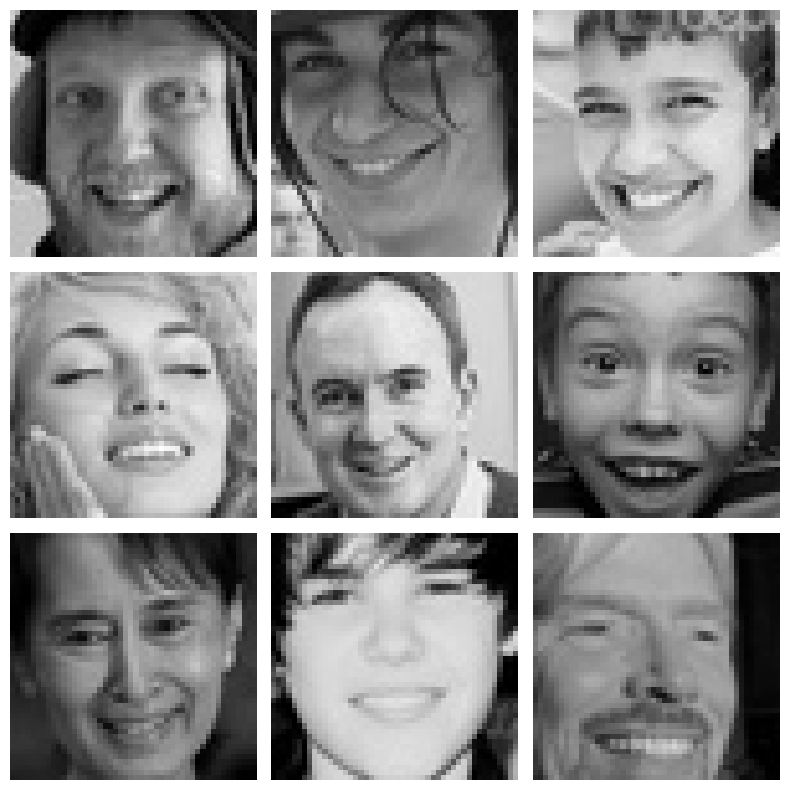

In [4]:
head_images(df_images, "happy")

**Observations and Insights:**
+ Facial orientation is often straight forward, or uplifted
+ Eye lids are variable, ranging from wide open to squinting.  Most people's eye's narrow when they smile due to facial muscles raising their cheeks while grinning.
+ The mouth will generally be wider than resting, as a grin will stretch expand the face with muscles flexing in the cheek, upper and lower lips
+ Teeth are often exposed due to the lips spreading during a smile
+ Eyebrows can often be raised as an expression of excitement or joy
+ The corners of the lips are often upturned in relation to the rest of the mouth.

### **Sad**

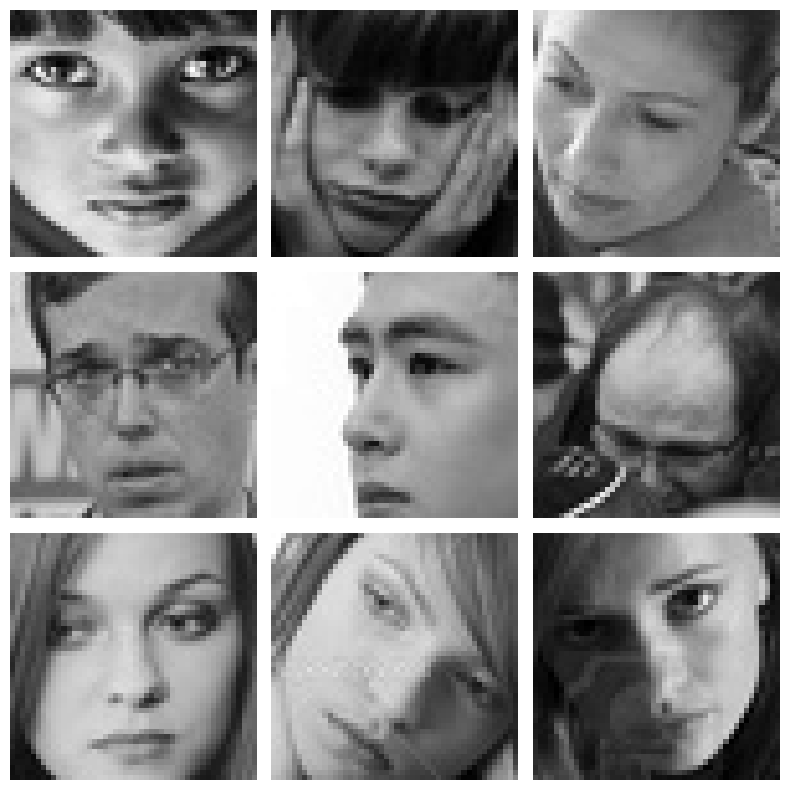

In [5]:
head_images(df_images, "sad")

**Observations and Insights:**
+ Facial orientation is often down, with subjects looking down, either avoiding direct contact, or lost in contemplation.
+ Facial features are largely relaxed, but with muscles in the lower face and jaw pulling tight on the lips.
+ Frowns or downturned lips, opposite of a smile, as well as furrowed brows, are common.

### **Neutral**

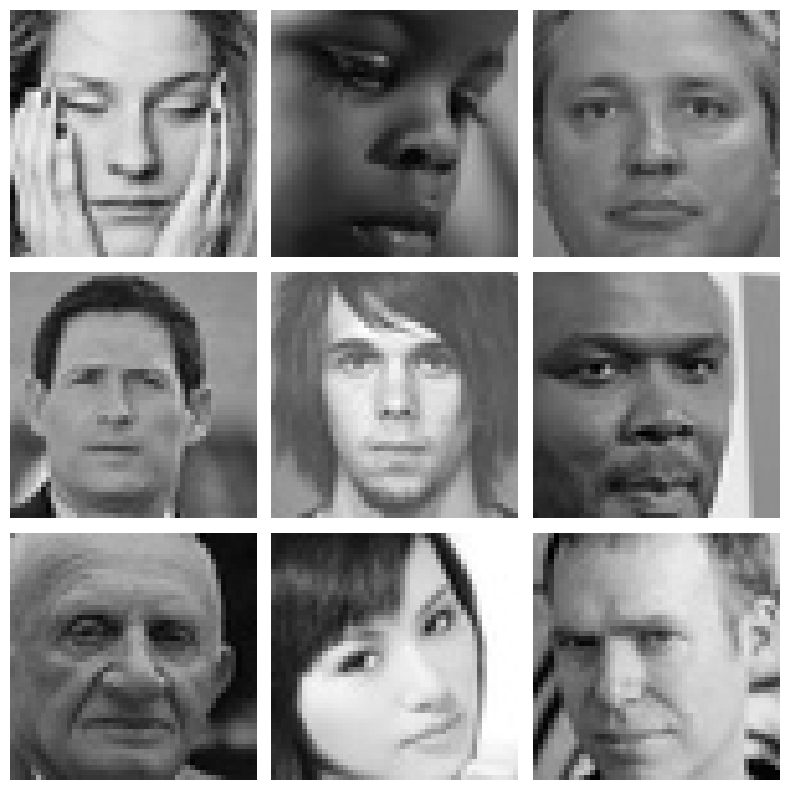

In [6]:
head_images(df_images, "neutral")

**Observations and Insights:**
+ 'Neutral' is a lot like happy.  However, it is dominated by a lot of facial features that are relaxed, with little to no muscle tension.
+ This is likely due to the fact that the subjects are not actively engaged in any particular emotion, and are simply observing the camera.
+ This may be a challenging emotion to distinguish from 'happy', as the facial features are similar, but the emotions are different.

### **Surprised**

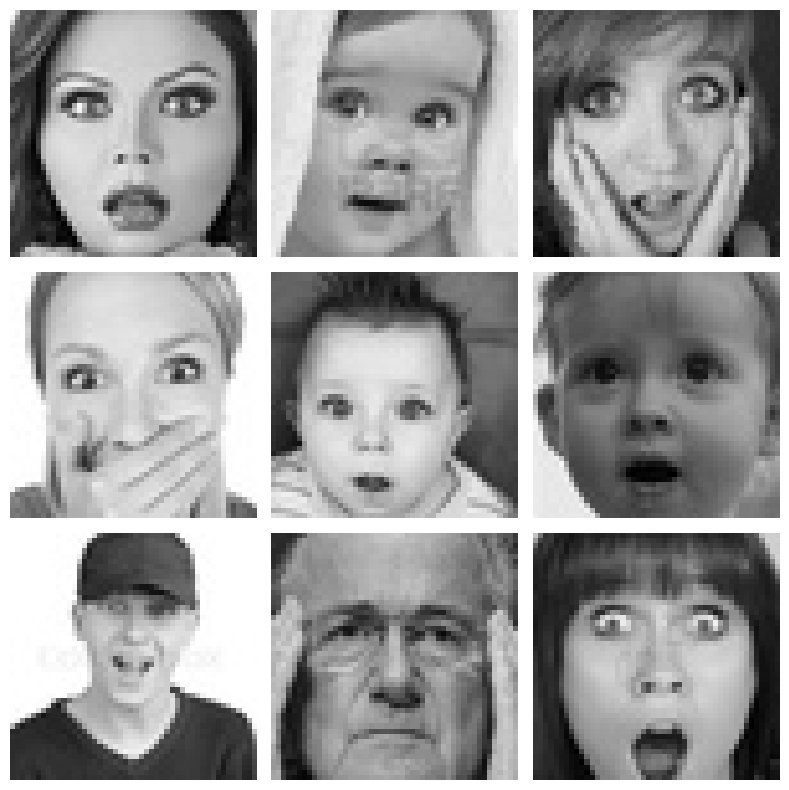

In [7]:
head_images(df_images, "surprise")

**Observations and Insights:**
+ Surprise has several strong characteristics
    + Hands are often held around the face
    + Mouths are open, due to adrenaline increasing heart rate and breathing, or screaming
    + Eyes are wide open, allowing more information to be clearly taken in
    + Eyebrows are high
    + nostrils are flared
    + Eyes are alert, with dialated pupils, and are actively looking around the environment

## Dataset EDA

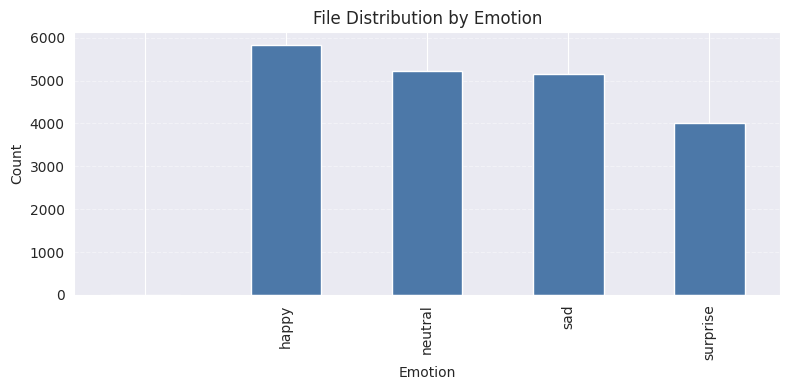

In [8]:
# Plotting a distribution of classes
counts = df_images["label"].value_counts().sort_index()
plt.figure(figsize=(8, 4))
counts.plot(kind="bar", color="#4C78A8")
plt.title("File Distribution by Emotion")
plt.xlabel("Emotion")
plt.ylabel("Count")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

### Observations
+ "happy", "neutral", and "sad" all feature between 5,000 and 6,000 images
+ "surprise" has 20% fewer candidates. We may consider using subsets from the larger groups to ensure that each emotion has equal representation for training.
+ The validation sets are not all equally sized, with 'happy' maintaining a 35% margin over the next largest expression, neutral.
    + We will not be using the predefined sets indicated in the initial folder structure of the data.

Checking for duplicates
Found 865 duplicate groups, 1896 duplicate entries total.


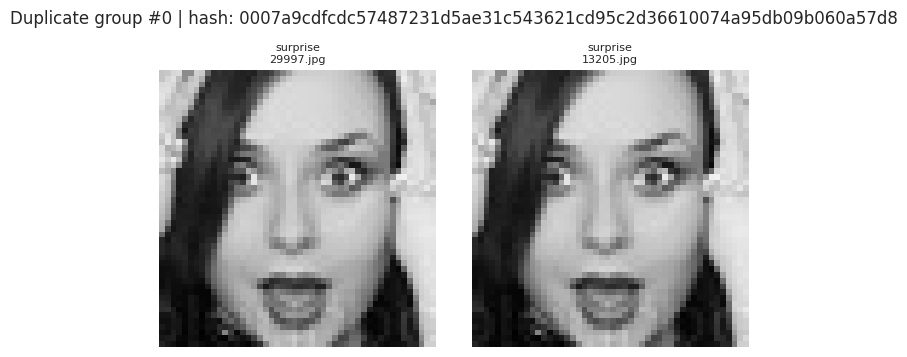

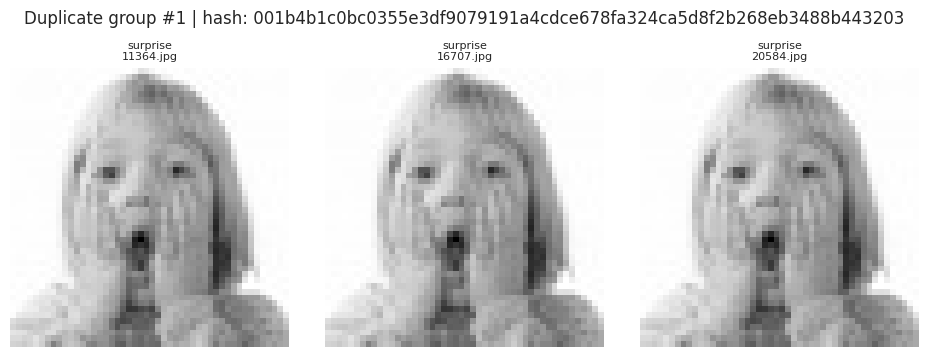

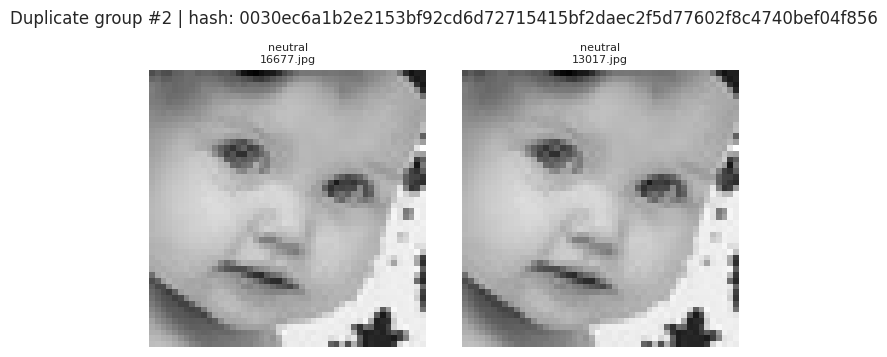

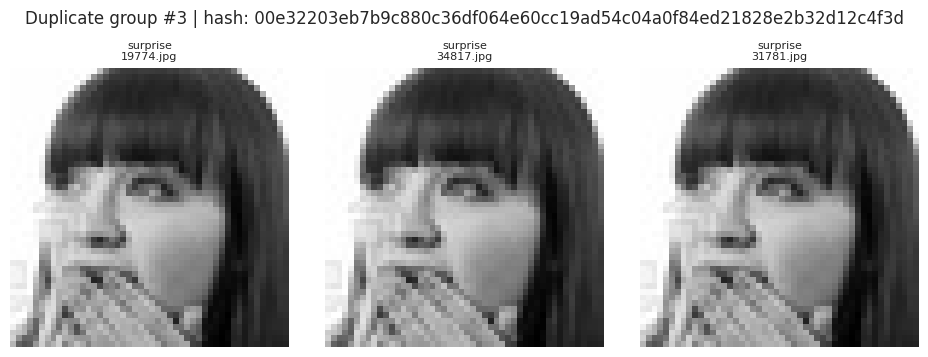

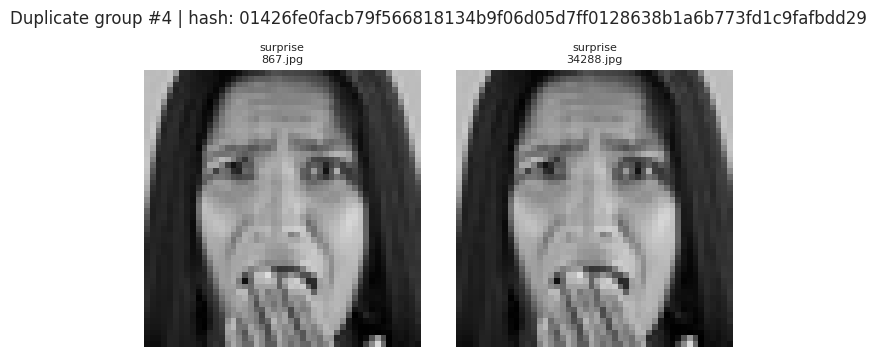

In [9]:
print("Checking for duplicates")
duplicates_df = eda_hash_duplicates(df_images)
if duplicates_df.empty:
    print("No duplicate files found.")
else:
    print(f"Found {duplicates_df['sha256'].nunique()} duplicate groups, {len(duplicates_df)} duplicate entries total.")

show_duplicate_images(duplicates_df, 5)

### Observations
With a total of 1896 duplicate entries, 9% of the set are duplications.  These will be removed.

In [10]:
summary = remove_duplicate_entries(df_images, duplicates_df, keep="first")
print(f"Removed {len(summary['removed'])} files; kept {len(summary['kept'])}.")

Removed 1031 files; kept 19186.


File Size Analysis


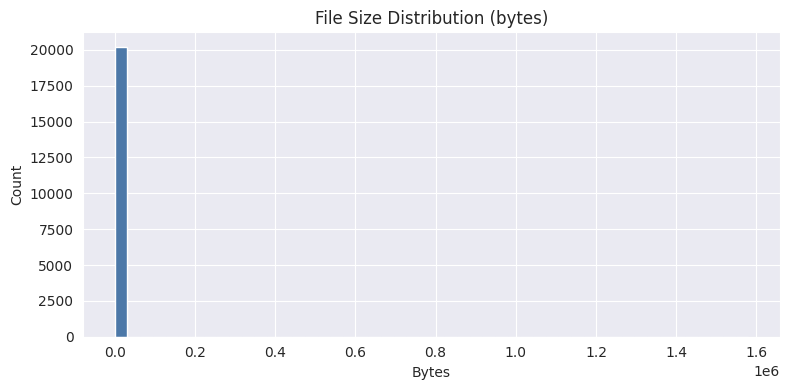

In [11]:
print("File Size Analysis")
eda_plot_file_size_distribution(df_images)

### Observations
We have a standard distribution of file sizes, with no real outliers.

Color Analysis


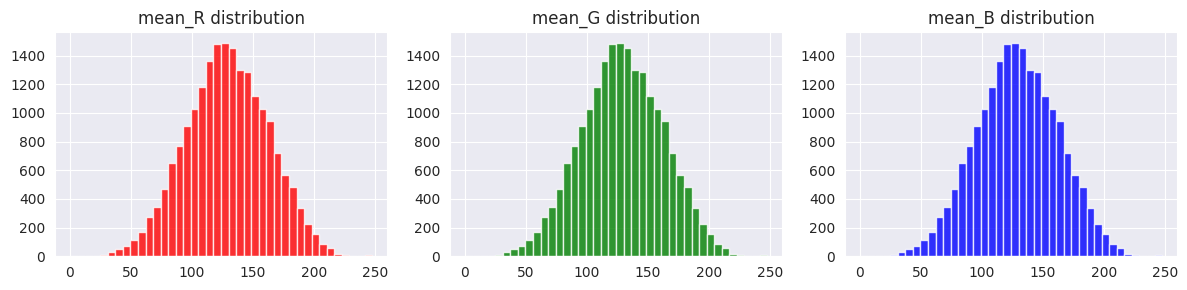

In [12]:
print("Color Analysis")
eda_plot_color_stats(df_images)

### Obsevations
We have a standard distribution of colors, with each channel identical, suggesting black and white images

Image Dimension Analysis


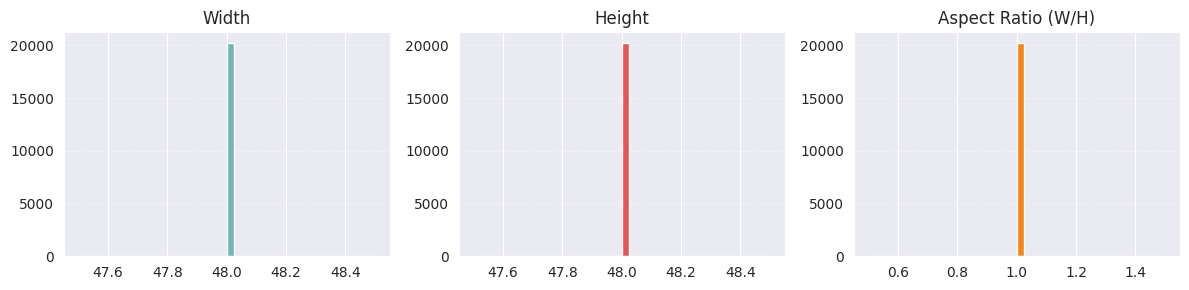

In [13]:
print("Image Dimension Analysis")
eda_plot_dimensions(df_images)

### Observations
All images are 48x48

Image Clarity Analysis


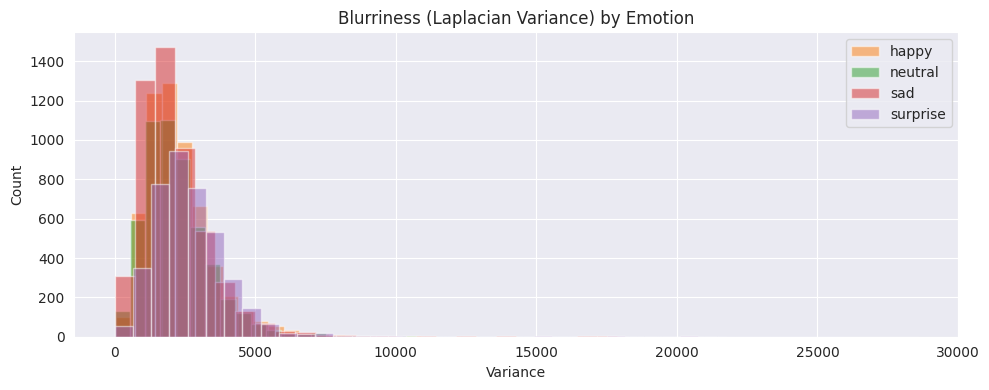

In [14]:
print("Image Clarity Analysis")
eda_plot_blurriness_by_label(df_images)

### Observations
Each set features the same general range of image quality, indicating that quality bias will not be an issue

Image Brightness Analysis


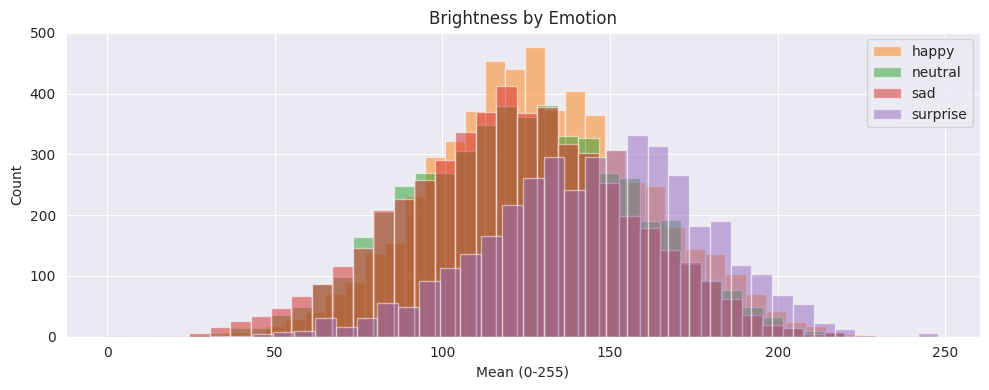

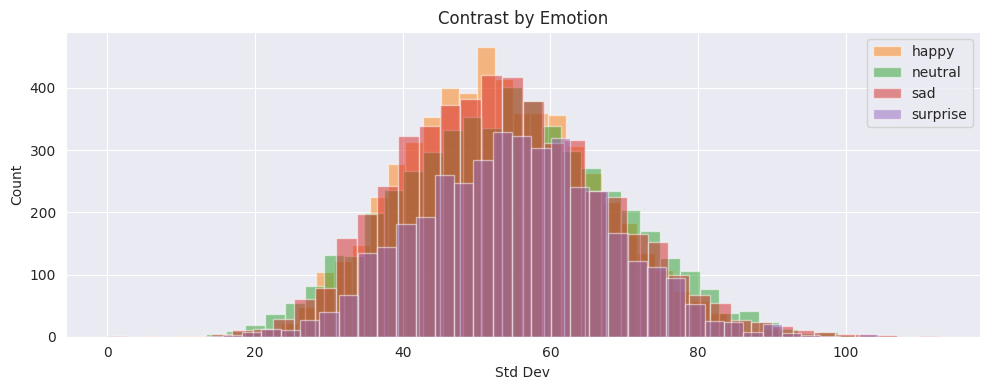

In [15]:
print("Image Brightness Analysis")
eda_plot_brightness_contrast_by_label(df_images)

### Observations
+ Each image collection features similar extents for a normal distribution over Brightness and Contrast.
+ Interesting to note that happy has the brightest images and greatest contrast, while neutral has the lowest.
+ We may need to brighten the surprise set to bring it into parity with the other sets.

## **Creating our Data Loaders**

We have identified two deficiencies with the datasets in terms of inequalities between the ratios of training and validation.  We have also established that the test sets have inadequate allocations to ensure that we have a good model.  Since we have a smaller dataset, we're going to go with a more liberal approach to give our validation and test sets the largest allocation.  We have over 20k images in our dataset, but we're really training with four separate subdivisions of 4 - 5k.  With smaller datasets, we want to increase the percentage of validation and test relative to train in order to ensure that we have enough candidates to ensure model validity in training and the field.  Thus, instead of a standard %80 / %10 / %10, we'll use a 75% / 12.5% / 12.5% for train, validate, and test, respectively (see: Ng, Géron, Chollet, Goodfellow, et, al).

In [16]:
batch_size  = 32
img_size = 48

set_seeds(65)

df_images_clean = df_images[df_images['label'].str.strip() != ''].copy()

print(f"Removed {len(df_images) - len(df_images_clean)} entries with empty labels")
print(f"Unique labels: {sorted(df_images_clean['label'].unique())}")

# Split df_images into training and test sets (12.5% test)
df_train_val, df_test = train_test_split(
    df_images_clean,
    test_size=0.125,
    stratify=df_images_clean['label'],
)

df_train, df_val = train_test_split(
    df_train_val,
    test_size=0.143, # This gives 12.5% of original
    stratify=df_train_val['label'],
)

# Encode labels
label_encoder = LabelEncoder()
df_train['label_encoded'] = label_encoder.fit_transform(df_train['label'])
df_val['label_encoded'] = label_encoder.transform(df_val['label'])
df_test['label_encoded'] = label_encoder.transform(df_test['label'])
num_classes = len(label_encoder.classes_)
print("Classes found by label_encoder:")
print(label_encoder.classes_)
print(f"\nNumber of classes: {len(label_encoder.classes_)}")

Removed 3 entries with empty labels
Unique labels: ['happy', 'neutral', 'sad', 'surprise']
Classes found by label_encoder:
['happy' 'neutral' 'sad' 'surprise']

Number of classes: 4


In [17]:
# Create base datasets.  These can be processed either as 1 channel or 3 channel images
train_dataset_base = tf.data.Dataset.from_tensor_slices((
    df_train['filename'].values,
    df_train['label_encoded'].values
))
train_dataset_base = train_dataset_base.shuffle(len(df_train))
train_dataset_base = train_dataset_base.map(load_and_preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
train_dataset_base = train_dataset_base.map(augment_image, num_parallel_calls=tf.data.AUTOTUNE)

val_dataset_base = tf.data.Dataset.from_tensor_slices((
    df_val['filename'].values,
    df_val['label_encoded'].values
))
val_dataset_base = val_dataset_base.map(load_and_preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)

test_dataset_base = tf.data.Dataset.from_tensor_slices((
    df_test['filename'].values,
    df_test['label_encoded'].values
))
test_dataset_base = test_dataset_base.map(load_and_preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)

# Create both datasets
train_dataset_rgb, val_dataset_rgb, test_dataset_rgb = prepare_datasets(
    train_dataset_base, val_dataset_base, test_dataset_base,
    color_mode='rgb',
    batch_size=batch_size,
    img_size=img_size
)

train_dataset_gs, val_dataset_gs, test_dataset_gs = prepare_datasets(
    train_dataset_base, val_dataset_base, test_dataset_base,
    color_mode='grayscale',
    batch_size=batch_size,
    img_size=img_size
)

I0000 00:00:1760566060.286763    1986 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 20482 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4090, pci bus id: 0000:10:00.0, compute capability: 8.9


Training Set, 474 elements
Image size: 48x48, Channels: 3


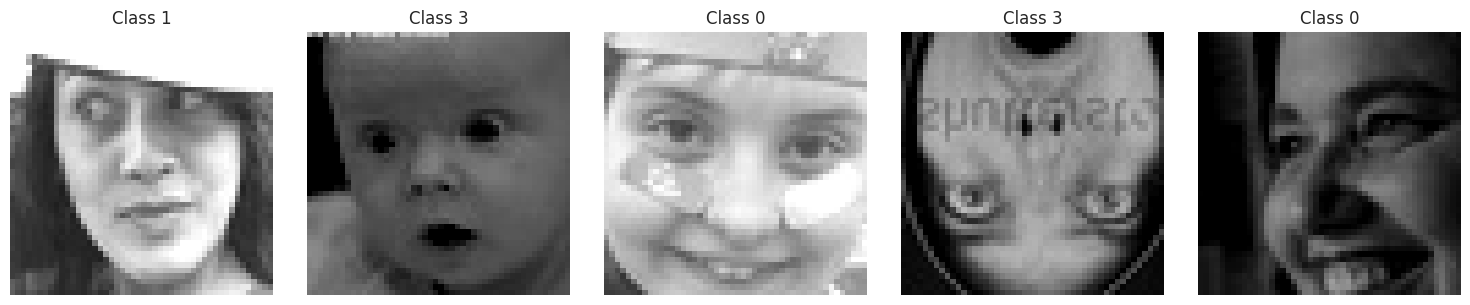

In [18]:
print("Training Set,", len(train_dataset_rgb), "elements")
head_dataset(train_dataset_rgb)

Validation Set, 80 elements
Image size: 48x48, Channels: 3


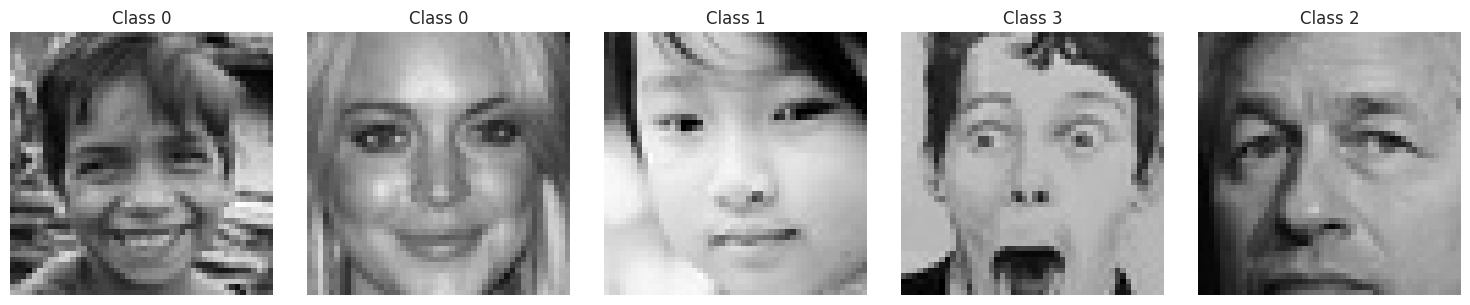

In [19]:
print("Validation Set,", len(val_dataset_rgb), "elements")
head_dataset(val_dataset_rgb)

Test Set, 79 elements
Image size: 48x48, Channels: 3


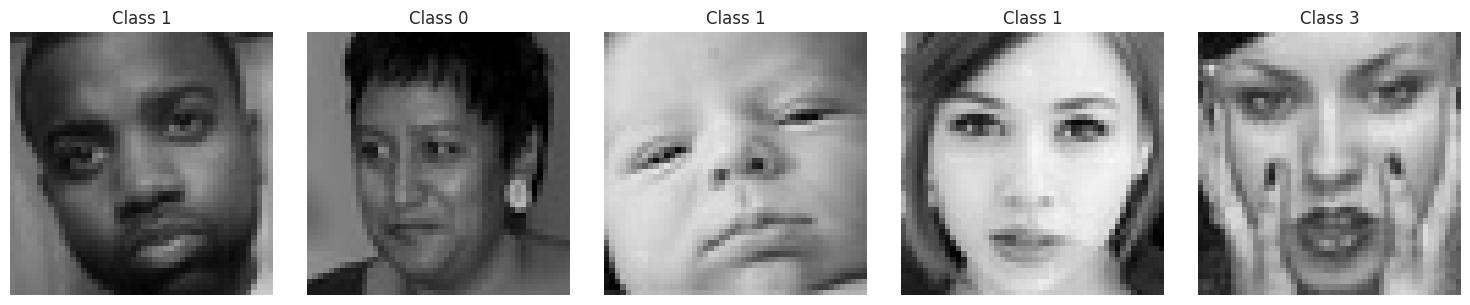

In [20]:
print("Test Set,", len(test_dataset_rgb), "elements")
head_dataset(test_dataset_rgb)

## **Model Building**

For the initial modeling attempts, we're going to use convolutional network architectures instead of the traditional ANN configuration.

Why?

In a nutshell, ANNs will overfit with image data.  Because ANN processing converts images to a single, 1D array of binary inputs, the spatial features of the image are basically lost.  The critical information encoded in an image is not just color values and luminance, but also spatial relationships.  While these relationships still persist despite the dimensional conversion, they are not easily detected by an ANN.  The result is overfitting to a given training set, while performing poorly when encountering new images, or when generalizing.

CNNs address this by creating 2D filters that scan an entire image in its original 2D format. These filters learn to recognize the features that are so important to classification, and become adept at generalization and handling error.

We are also going to run this initial model against 1 and 3 channel images to see how they compare.


### **Creating the Base Neural Network**

In [21]:
def cnn_model_1(input_channels=3):
    """
    Build a basic CNN model.

    Args:
        input_channels: Number of input channels (1 for grayscale, 3 for RGB)
    """
    model = Sequential()
    # Input shape = (48, 48, input_channels)
    model.add(Input(shape=(48, 48, input_channels)))
    # First Convolutional layer with 16 filters, kernel size 3x3, same padding
    model.add(Conv2D(16, kernel_size=(3, 3), padding='same'))

    # LeakyReLU activation with slope 0.1
    model.add(LeakyReLU(negative_slope=0.1))

    # Second Convolutional layer with 32 filters, kernel size 3x3, same padding
    model.add(Conv2D(32, kernel_size=(3, 3), padding='same'))

    # LeakyReLU activation with slope 0.1
    model.add(LeakyReLU(negative_slope=0.1))

    # Max pooling layer with pool size 2x2
    model.add(MaxPooling2D(pool_size=(2, 2)))

    # Flatten the output from previous layer
    model.add(Flatten())

    # Dense layer with 32 nodes
    model.add(Dense(32))

    # LeakyReLU activation with slope 0.1
    model.add(LeakyReLU(negative_slope=0.1))

    # Output layer with 4 nodes (number of classes) and softmax activation
    model.add(Dense(4, activation='softmax'))

    # Compile the model
    model.compile(
        loss='categorical_crossentropy',
        optimizer=Adam(learning_rate=0.001),
        metrics=['accuracy']
    )

    return model

#### Create the grayscale model, fit it, and analyze it

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 48, 48, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │       589,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 594,788 (2.27 MB)

 Trainable params: 594,788 (2.27 MB)

 Non-trainable params: 0 (0.00 B)

...

I0000 00:00:1760566071.390203    2281 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


474/474 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3365 - loss: 1.3329

2025-10-15 18:07:55.439163: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_103', 8 bytes spill stores, 8 bytes spill loads

2025-10-15 18:07:55.496668: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_103', 12 bytes spill stores, 12 bytes spill loads



474/474 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.3945 - loss: 1.2715 - val_accuracy: 0.5470 - val_loss: 1.0742
Epoch 2/15
474/474 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.4996 - loss: 1.1160 - val_accuracy: 0.5846 - val_loss: 0.9544
Epoch 3/15
474/474 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5547 - loss: 1.0303 - val_accuracy: 0.5810 - val_loss: 0.9738
Epoch 4/15
474/474 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5766 - loss: 0.9782 - val_accuracy: 0.6130 - val_loss: 0.8971
Epoch 5/15
474/474 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6042 - loss: 0.9326 - val_accuracy: 0.6257 - val_loss: 0.8807
Epoch 6/15
474/474 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6204 - loss: 0.8988 - val_accuracy: 0.6328 - val_loss: 0.8704
Epoch 7/15
474/474 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6386 - loss: 0.8609 - val_accuracy: 0.6324 - val_loss: 0.8740
Epoch 8/15
474/474 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6545 - loss: 0.8312 - val_accuracy: 0.6285 - val

2025-10-15 18:08:41.420029: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


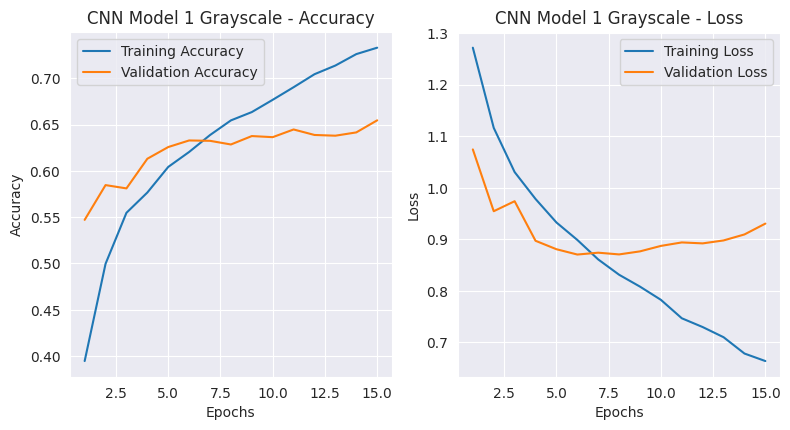


CNN Model 1 Grayscale - Test Results Summary
Test Loss:     0.9163
Test Accuracy: 0.6498 (64.98%)

Training Metrics:
  Final Training Accuracy:   0.7330
  Final Validation Accuracy: 0.6545
  Final Training Loss:       0.6639
  Final Validation Loss:     0.9304

79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Classification Report
               precision    recall  f1-score   support

           0       0.71      0.69      0.70       729
           1       0.56      0.60      0.58       654
           2       0.55      0.60      0.58       644
           3       0.86      0.71      0.78       500

    accuracy                           0.65      2527
   macro avg       0.67      0.65      0.66      2527
weighted avg       0.66      0.65      0.65      2527



2025-10-15 18:08:41.964949: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
/tmp/ipykernel_1986/3391108090.py:492: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_updated = pd.concat([df_results, pd.DataFrame([new_row])], ignore_index=True)


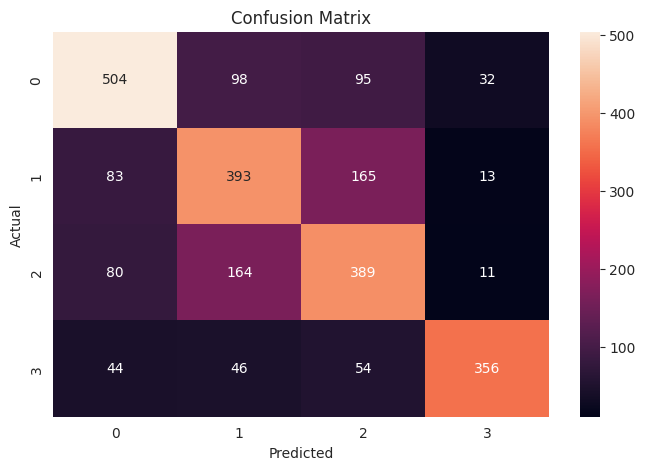

In [22]:
cnn_model_1_gs = cnn_model_1(input_channels=1)

# Print the model summary
cnn_model_1_gs.summary()

# Fit the model
history_cnn_model_1_gs = cnn_model_1_gs.fit(
    train_dataset_gs,
    epochs=15,
    validation_data=val_dataset_gs,
    verbose=1
)

df_results = evaluate_predict_and_report(df_results, test_dataset=test_dataset_gs, model_instance=cnn_model_1_gs, history=history_cnn_model_1_gs, model_name="CNN Model 1 Grayscale")

#### Now we will try the second pass with an RGB model

In [23]:
cnn_model_1_rgb = cnn_model_1(input_channels=3)

# Print the model summary
cnn_model_1_rgb.summary()

# Fit the model
history_cnn_model_1_rgb = cnn_model_1_rgb.fit(
    train_dataset_rgb,
    epochs=15,
    validation_data=val_dataset_rgb,
    verbose=0
)

df_results = evaluate_predict_and_report(df_results, test_dataset=test_dataset_rgb, model_instance=cnn_model_1_rgb, history=history_cnn_model_1_rgb, model_name="CNN Model 1 RGB")

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 48, 48, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 48, 48, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 48, 48, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │       589,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 595,076 (2.27 MB)

 Trainable params: 595,076 (2.27 MB)

 Non-trainable params: 0 (0.00 B)

KeyboardInterrupt: 

### **Evaluating the Model on the Test Set**

To answer the question as to the performance differences between grayscale and rgb?  Let's graph a comparison.

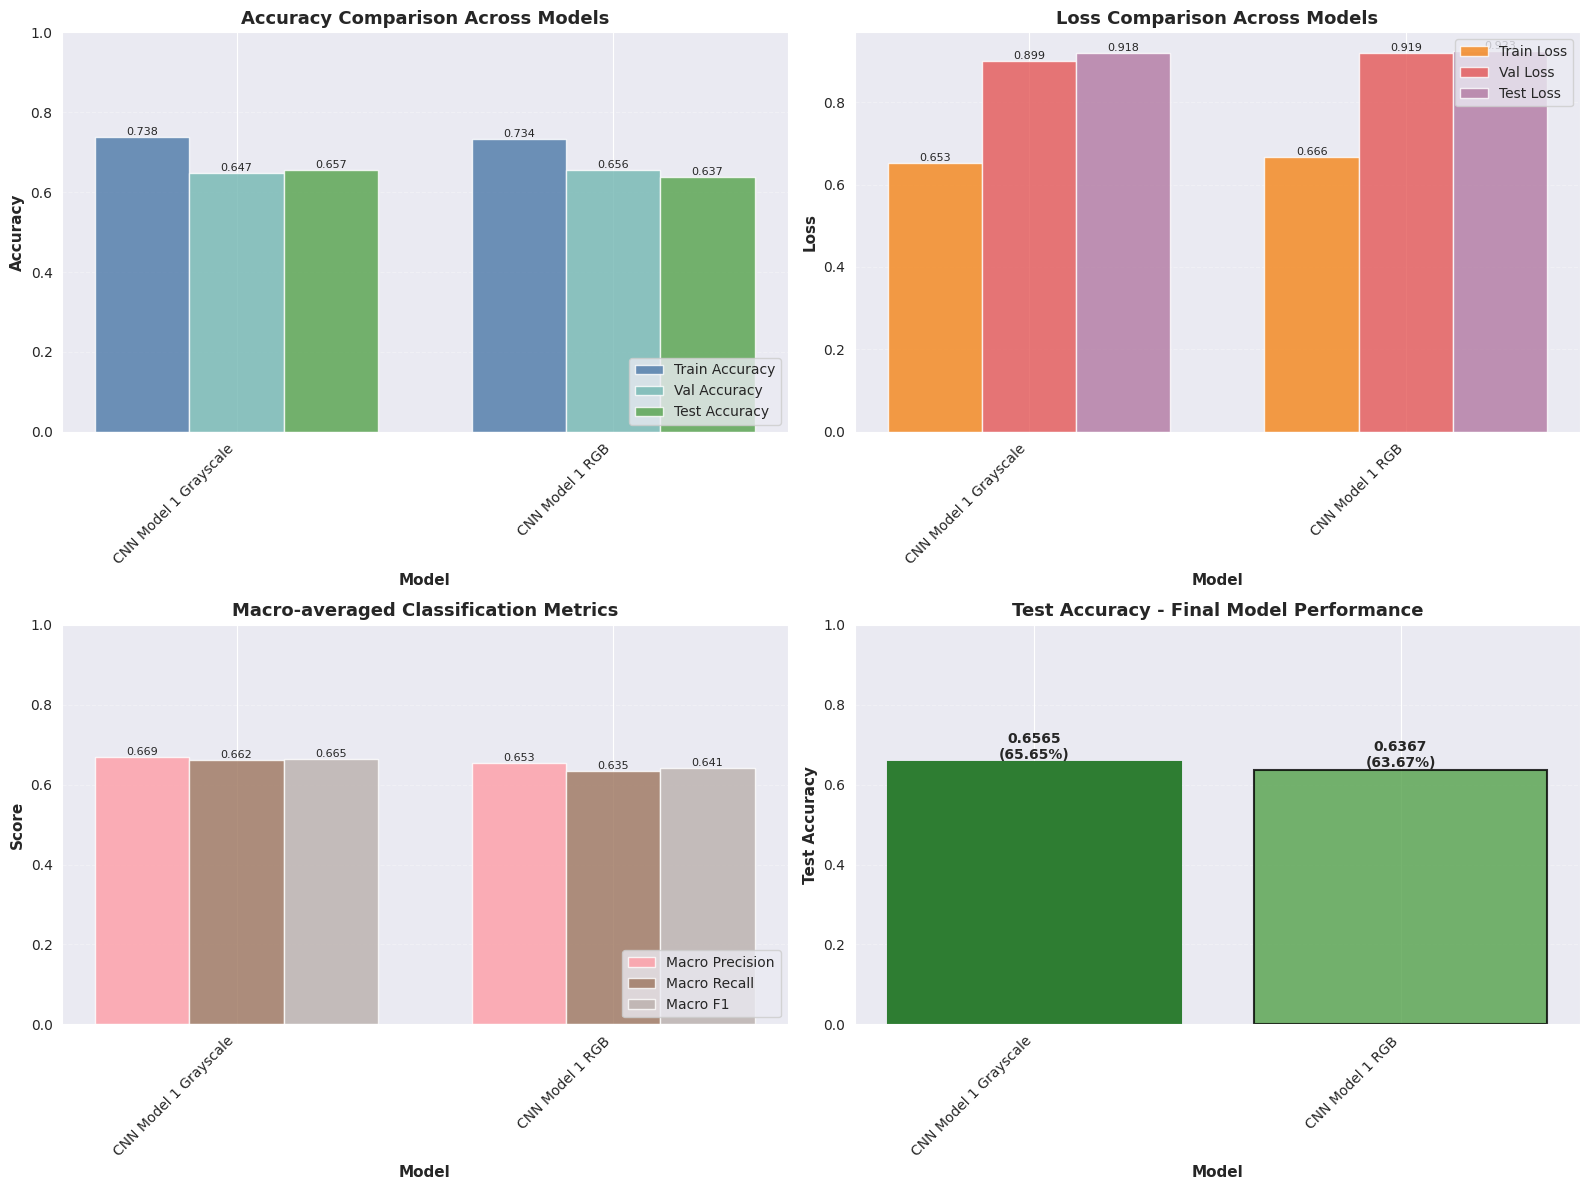


MODEL COMPARISON SUMMARY
                 name epochs  train_loss  train_accuracy  val_loss  val_accuracy  test_loss  test_accuracy  macro_precision  macro_recall  macro_f1
CNN Model 1 Grayscale     15    0.652835        0.737877  0.898768      0.647036   0.918366       0.656510         0.669471      0.661706  0.664836
      CNN Model 1 RGB     15    0.666003        0.733588  0.918800      0.655731   0.923138       0.636723         0.653318      0.634651  0.641362

🏆 BEST MODEL: CNN Model 1 Grayscale
   Test Accuracy: 0.6565 (65.65%)
   Test Loss: 0.9184
   Macro F1 Score: 0.6648



In [24]:
plot_model_comparison(df_results)

**Observations and Insights:**
+ The RGB dataset produced results (F1 scoring) that were better than the grayscale results, though by a margin of 1%, which is within a margin of error.
+ As indicated by analysis logic, overfitting has been detected.
+ The maximum F1 score during test, at 64%, was poor and not ready for production
+ The loss analysis also suggests uncertainty about predictions.
+ The confusion matrix also shows off-identity scores that range from 15% - 50%, which indicate that the model is not confident in its predictions for these classes.

### **Creating the second Convolutional Neural Network**

Try out the following improvements:
+ Larger architecture with more layers
+ Increase the size of the convolutional filters and the pooling layers in order to allow for more information in these passes
+ A dropout layer will be used to prevent overfitting
+ 30 epochs will be used, and we'll see what generation achieves the greatest accuracy

In [25]:
# First clear up the back-end
backend.clear_session()
set_seeds(2025)

### **Second Model Architecture**

- First Convolutional layer with **16 filters and the kernel size of 5x5**. Use the **'same' padding** and provide the **input shape = (48, 48, 3)**
- Add a **LeakyRelu layer** with the **slope equal to 0.1**
- Second Convolutional layer with **32 filters and the kernel size of 3x3 with 'same' padding**
- Add **LeakyRelu** with the **slope equal to 0.1**
- Add a **max-pooling layer** with a **pool size of 5x5**
- Add a **BatchNormalization layer**
- Third Convolutional layer with **32 filters and the kernel size of 5x5 with 'same' padding**
- Add a **LeakyRelu layer with the slope equal to 0.1**
- Fourth Convolutional layer **64 filters and the kernel size of 5x5 with 'same' padding**
- Add a **LeakyRelu layer with the slope equal to 0.1**
- Add a **max-pooling layer** with a **pool size of 5x5**
- Add a **BatchNormalization layer**
- **Flatten** the output from the previous layer
- Add a **dense layer with 32 nodes**
- Add a **LeakyRelu layer with the slope equal to 0.1**
- Add a **dropout layer with the rate equal to 0.5**
- Add the final **output layer with nodes equal to the number of classes, i.e., 4** and **'softmax' as the activation function**
- Compile the model with the **categorical_crossentropy loss, adam optimizers (learning_rate = 0.001), and metric equal to 'accuracy'**. Do not fit the model here, just return the compiled model.
- Call the function cnn_model_2 and store the model in a new variable.
- Print the summary of the model.
- Fit the model on the train data with a **validation split of 0.2, batch size = 128, verbose = 1, and epochs = 30**. Store the model building history to use later for visualization.

In [26]:
def cnn_model_2(input_channels=3):
    """
    Build a CNN model with deeper architecture for improved performance.

    Args:
        input_channels: Number of input channels (1 for grayscale, 3 for RGB)
    """
    model = Sequential()
    # Input shape = (48, 48, input_channels)
    model.add(Input(shape=(48, 48, input_channels)))
    # First Convolutional layer with 16 filters, kernel size 5x5, same padding
    model.add(Conv2D(16, kernel_size=(5, 5), padding='same'))
    # LeakyReLU activation with slope 0.1
    model.add(LeakyReLU(negative_slope=0.1))
    # Second Convolutional layer with 32 filters, kernel size 3x3, same padding
    model.add(Conv2D(32, kernel_size=(5, 5), padding='same'))
    # LeakyReLU activation with slope 0.1
    model.add(LeakyReLU(negative_slope=0.1))
    # Max pooling layer with pool size 2x2
    model.add(MaxPooling2D(pool_size=(5, 5)))
    # BatchNormalization layer
    model.add(BatchNormalization())
    # Third Convolutional layer with 32 filters, kernel size 3x3, same padding
    model.add(Conv2D(32, kernel_size=(5, 5), padding='same'))
    # LeakyReLU activation with slope 0.1
    model.add(LeakyReLU(negative_slope=0.1))
    # Fourth Convolutional layer with 64 filters, kernel size 3x3, same padding
    model.add(Conv2D(64, kernel_size=(5, 5), padding='same'))
    # LeakyReLU activation with slope 0.1
    model.add(LeakyReLU(negative_slope=0.1))
    # Max pooling layer with pool size 2x2
    model.add(MaxPooling2D(pool_size=(5, 5)))
    # BatchNormalization layer
    model.add(BatchNormalization())
    # Flatten the output from previous layer
    model.add(Flatten())
    # Dense layer with 32 nodes
    model.add(Dense(32))
    # LeakyReLU activation with slope 0.1
    model.add(LeakyReLU(negative_slope=0.1))
    # Dropout layer with rate 0.5
    model.add(Dropout(0.3))
    # Output layer with 4 nodes (number of classes) and softmax activation
    model.add(Dense(4, activation='softmax'))
    # Compile the model
    model.compile(
        loss='categorical_crossentropy',
        optimizer=Adam(learning_rate=0.001),
        metrics=['accuracy']
    )

    return model

# Build the model by calling the function
cnn_model_2_instance = cnn_model_2(1)

# Print the model summary
cnn_model_2_instance.summary()

# Fit the model
history_cnn_model_2 = cnn_model_2_instance.fit(
    train_dataset_gs,
    epochs=15,
    validation_data=val_dataset_gs,
    verbose=0
)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 48, 48, 16)     │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_6 (LeakyReLU)       │ (None, 48, 48, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 48, 48, 32)     │        12,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_7 (LeakyReLU)       │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 9, 9, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 9, 9, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 9, 9, 32)       │        25,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_8 (LeakyReLU)       │ (None, 9, 9, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 9, 9, 64)       │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_9 (LeakyReLU)       │ (None, 9, 9, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 1, 1, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1, 1, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_10 (LeakyReLU)      │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 92,740 (362.27 KB)

 Trainable params: 92,548 (361.52 KB)

 Non-trainable params: 192 (768.00 B)

### Observations
+ Much better accuracy for validation at 71%
+ Given the model was originally trained to recognize numeric digits, this is surprising
+ 70% is still too low to be truly useful in production.

### **Evaluating the Model on the Test Set**

79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.7060 - loss: 0.7330

FINAL TRAINING STATISTICS

Total Epochs Completed: 15

Metric                    Training        Validation     
------------------------------------------------------------
Loss                      0.7865          0.7176         
Accuracy                  0.6746          0.7087         


Overfitting Gap (Train - Val Accuracy): -0.0341
✓ Model appears to generalize well

Best Validation Accuracy: 0.7087 at epoch 15


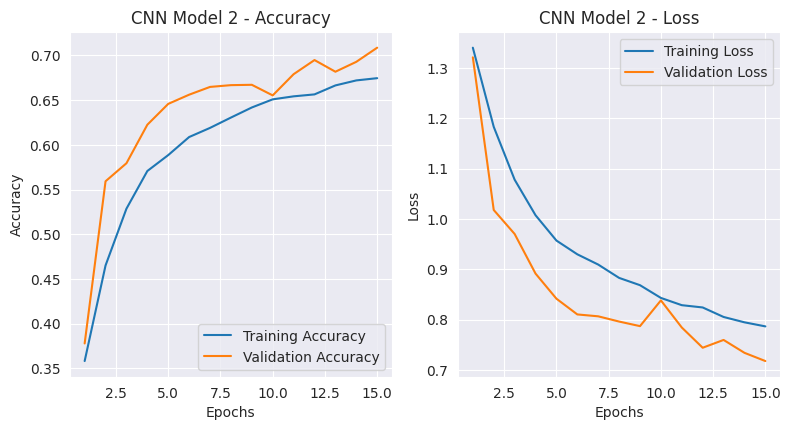


CNN Model 2 - Test Results Summary
Test Loss:     0.7330
Test Accuracy: 0.7060 (70.60%)

Training Metrics:
  Final Training Accuracy:   0.6746
  Final Validation Accuracy: 0.7087
  Final Training Loss:       0.7865
  Final Validation Loss:     0.7176

79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Classification Report
               precision    recall  f1-score   support

           0       0.84      0.71      0.77       729
           1       0.62      0.66      0.64       654
           2       0.58      0.68      0.63       644
           3       0.87      0.79      0.83       500

    accuracy                           0.71      2527
   macro avg       0.73      0.71      0.72      2527
weighted avg       0.72      0.71      0.71      2527



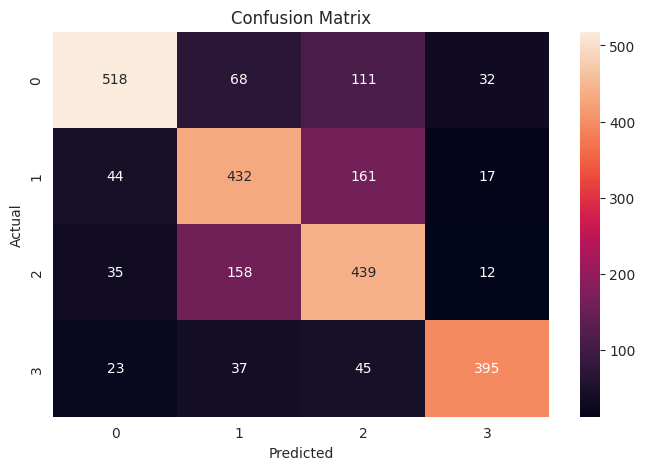

In [27]:
df_results = evaluate_predict_and_report(df_results, test_dataset=test_dataset_gs, model_instance=cnn_model_2_instance, history=history_cnn_model_2, model_name="CNN Model 2")

#### Observations
+ The new model avoided overfitting
+ It was able to classify test results with an F1 score of 70%.
+ Confusion matrix shows some classes still have high confusion rates, with over 50% for the worst cases.  This indicates that the model still has a hard time providing conviction in classification
+ 70% F1 is good, but we may be able to do better leveraging pre-existing trained models and transfer learing.
+ Pre-existing models may outperform these examples due to higher number of filters, more sophisticated model architecture, and a larger and more diverse training and validation set to produce the models.

## **Transfer Learning Architectures**

In this section, we will create several Transfer Learning architectures. For the pre-trained models, we will select three popular architectures namely, VGG16, ResNet v2, and Efficient Net. The difference between these architectures and the previous architectures is that these will require 3 input channels while the earlier ones worked on 'grayscale' images.  We will leverage the RGB dataset that we created earlier.

## **VGG16 Model**

#### Creating the datasets for VGG
Because we need images taht are 224x224, we need to alter our dataset.  We can use the pre-existing splits with our API, and just designate the size, as well as 3 color channels

Image size: 224x224, Channels: 3


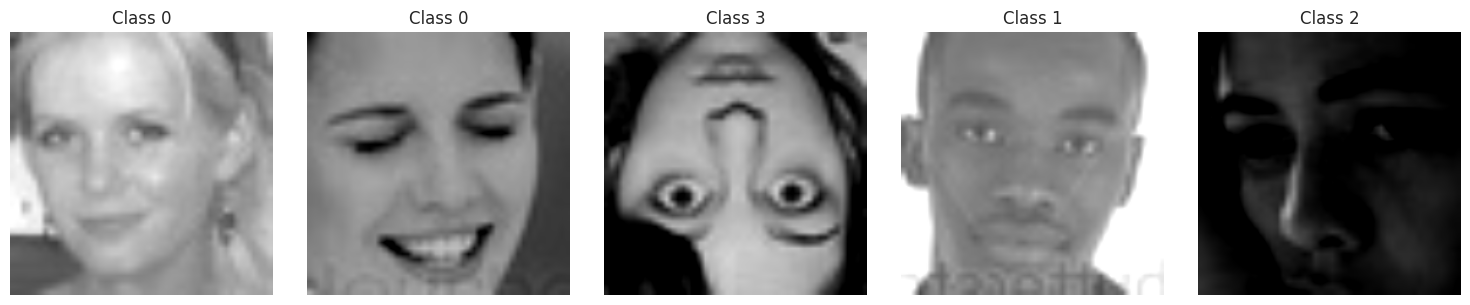

In [28]:
# First clear up the back-end
backend.clear_session()
set_seeds(20)

train_dataset_224_rgb, val_dataset_224_rgb, test_dataset_224_rgb = prepare_datasets(
    train_dataset_base, val_dataset_base, test_dataset_base,
    color_mode='rgb',
    batch_size=batch_size,
    img_size=224
)

head_dataset(train_dataset_224_rgb)

### **Model Building**

Import VGG16 and add Fully Connected layers on top of it.
+ Flatten the output from the base
+ Add a dense layer of 256 neurons, using relu
+ Add dropout with 0.3 ratio
+ Add a dense layer of 64 neurons, using relu
+ Add a batch normalization layer
+ Add the final output layer with 4 neurons and a sofmax

In [29]:
def create_vgg16_model(n_classes, fine_tune=False, input_shape = (224, 224, 3), optimizer='rmsprop'):
    """
    Compiles a model using vgg16 as a base, with the option of fine_tuning the existing layers

    input_shape: tuple - the shape of input images (width, height, channels)
    n_classes: int - The number of classes to categorize, shapes the softmax output layer
    optimizer: string - instantiated optimizer to use for training. Defaults to 'RMSProp'
    fine_tune: int - The number of pre-trained layers to unfreeze.
                If set to 0, all pretrained layers will freeze during training
    """

    # Include the base, without its top.  We'll provide an alternative
    conv_base = VGG16(include_top=False,
                     weights='imagenet',
                     input_shape=input_shape)

    # Defines how many layers to freeze during training.
    # Layers in the convolutional base are switched from trainable to non-trainable
    # depending on the size of the fine-tuning parameter.
    if fine_tune:
        for layer in conv_base.layers:
            if "conv" in layer.name:
                layer.trainable = True
            else:
                layer.trainable = False
    else:
        conv_base.trainable = False

    # Create a simple model for extension:
    top_model = conv_base.get_layer('block5_pool').output
    top_model = Flatten(name="flatten")(top_model)
    top_model = Dense(256, activation='relu')(top_model)
    top_model = Dropout(0.3)(top_model)
    top_model = Dense(64, activation='relu')(top_model)
    top_model = BatchNormalization()(top_model)
    output_layer = Dense(n_classes, activation='softmax')(top_model)

    # Group the convolutional base and connected layers into a Model object.
    model = Model(inputs=conv_base.input, outputs=output_layer)

    # Compiles the model for training.
    model.compile(optimizer=optimizer,
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    return model


### **Compiling and Training the VGG16 Model**

In [30]:
vgg16_model_instance = create_vgg16_model(4, False)
vgg16_model_history = summarize_and_fit(vgg16_model_instance, "VGG16", train_dataset_224_rgb, val_dataset_224_rgb)

Model: "functional_35"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 21,154,436 (80.70 MB)

 Trainable params: 6,439,620 (24.57 MB)

 Non-trainable params: 14,714,816 (56.13 MB)

...

471/474 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.3624 - loss: 1.3908

2025-10-14 22:50:08.826944: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-10-14 22:50:08.827056: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-10-14 22:50:09.616654: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1397', 64 bytes spill stores, 64 bytes spill loads

2025-10-14 22:50:09.714341: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning :

474/474 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.3628 - loss: 1.3899

2025-10-14 22:50:12.917288: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-10-14 22:50:13.173765: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_265', 8 bytes spill stores, 8 bytes spill loads

2025-10-14 22:50:16.503288: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_265', 8 bytes spill stores, 8 bytes spill loads



474/474 ━━━━━━━━━━━━━━━━━━━━ 30s 49ms/step - accuracy: 0.4239 - loss: 1.2509 - val_accuracy: 0.5980 - val_loss: 0.9588 - learning_rate: 0.0010
Epoch 2/20
474/474 ━━━━━━━━━━━━━━━━━━━━ 15s 32ms/step - accuracy: 0.5223 - loss: 1.0834 - val_accuracy: 0.6071 - val_loss: 0.9018 - learning_rate: 0.0010
Epoch 3/20
474/474 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - accuracy: 0.5481 - loss: 1.0444 - val_accuracy: 0.6051 - val_loss: 0.9367 - learning_rate: 0.0010
Epoch 4/20
474/474 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - accuracy: 0.5731 - loss: 1.0056 - val_accuracy: 0.6372 - val_loss: 0.8735 - learning_rate: 0.0010
Epoch 5/20
474/474 ━━━━━━━━━━━━━━━━━━━━ 15s 31ms/step - accuracy: 0.5778 - loss: 0.9863 - val_accuracy: 0.6134 - val_loss: 0.8997 - learning_rate: 0.0010
Epoch 6/20
474/474 ━━━━━━━━━━━━━━━━━━━━ 13s 28ms/step - accuracy: 0.5837 - loss: 0.9724 - val_accuracy: 0.5901 - val_loss: 0.9381 - learning_rate: 0.0010
Epoch 7/20
474/474 ━━━━━━━━━━━━━━━━━━━━ 15s 31ms/step - accuracy: 0.5918 - loss: 0.9669

### Observations:
+ The VGG16 model uses multiple layers of convolution, separated by pooling layers.
+ The first two blocks feature two Conv2D layers feeding into pooling layers
+ Subsequent blocks have three Conv2D layers feeding into pooling layers.
+ No normalization is performed
+ The Conv2D layers start large and then decrease in size, this seems counterintuitive.
    + It could be assumed that smaller filters would be used to start with, identify sub-units of features
    + The output of these filters would then be processed into larger pools
    + Subsequent layers would be larger, assembling multiple features together in order to assess the state of the whole
        + Smaller pools would force the model to reduce the sum of all features into a smaller set of possible values
+ The best epoch was 18, indicating that 20 was a good choice for training and the learning rate was adequate for this number.

### **Evaluating the VGG16 model**

78/79 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6881 - loss: 0.7571

2025-10-14 22:54:50.477149: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-10-14 22:54:50.726327: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_265', 8 bytes spill stores, 8 bytes spill loads



79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 61ms/step - accuracy: 0.6953 - loss: 0.7572

FINAL TRAINING STATISTICS

Total Epochs Completed: 20

Metric                    Training        Validation     
------------------------------------------------------------
Loss                      0.8541          0.7633         
Accuracy                  0.6501          0.6822         


Overfitting Gap (Train - Val Accuracy): -0.0321
✓ Model appears to generalize well

Best Validation Accuracy: 0.6905 at epoch 12


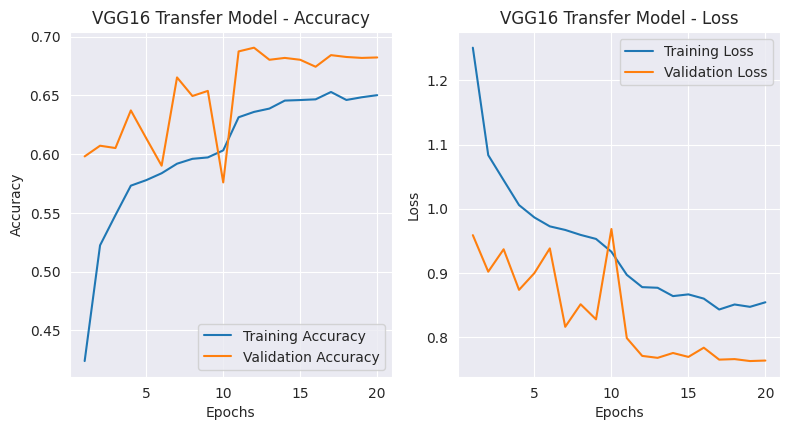


VGG16 Transfer Model - Test Results Summary
Test Loss:     0.7572
Test Accuracy: 0.6953 (69.53%)

Training Metrics:
  Final Training Accuracy:   0.6501
  Final Validation Accuracy: 0.6822
  Final Training Loss:       0.8541
  Final Validation Loss:     0.7633

79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step
Classification Report
               precision    recall  f1-score   support

           0       0.80      0.77      0.79       729
           1       0.59      0.63      0.61       654
           2       0.61      0.60      0.60       644
           3       0.80      0.79      0.79       500

    accuracy                           0.70      2527
   macro avg       0.70      0.70      0.70      2527
weighted avg       0.70      0.70      0.70      2527



2025-10-14 22:55:00.708397: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


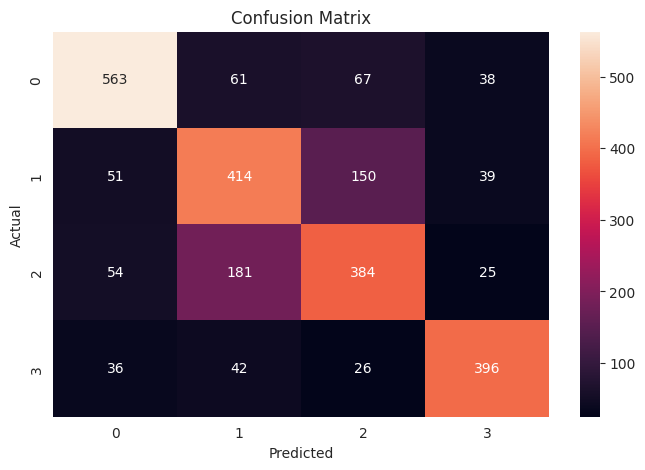

In [31]:
df_results = evaluate_predict_and_report(df_results, test_dataset=test_dataset_224_rgb, model_instance=vgg16_model_instance, history=vgg16_model_history, model_name="VGG16 Transfer Model")

#### Observations:
+ 76% F1 Score is the highest so far
+ Confusion matrix shows the greatest conviction on predictions
+ Recall and precision are also high

Can we do better?  Let's try to fine tune.

In [32]:
fine_tune_model(vgg16_model_instance, train_dataset_224_rgb, val_dataset_224_rgb, "vgg16_tuned")

Epoch 1/20
473/474 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.5490 - loss: 1.0682

2025-10-14 22:55:56.348711: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1954', 4 bytes spill stores, 4 bytes spill loads



474/474 ━━━━━━━━━━━━━━━━━━━━ 70s 117ms/step - accuracy: 0.5992 - loss: 0.9599 - val_accuracy: 0.7126 - val_loss: 0.7053 - learning_rate: 5.0000e-05
Epoch 2/20
474/474 ━━━━━━━━━━━━━━━━━━━━ 43s 91ms/step - accuracy: 0.6627 - loss: 0.8233 - val_accuracy: 0.6391 - val_loss: 0.8489 - learning_rate: 5.0000e-05
Epoch 3/20
474/474 ━━━━━━━━━━━━━━━━━━━━ 42s 89ms/step - accuracy: 0.6841 - loss: 0.7740 - val_accuracy: 0.7494 - val_loss: 0.6313 - learning_rate: 5.0000e-05
Epoch 4/20
474/474 ━━━━━━━━━━━━━━━━━━━━ 42s 88ms/step - accuracy: 0.7048 - loss: 0.7392 - val_accuracy: 0.7375 - val_loss: 0.6574 - learning_rate: 5.0000e-05
Epoch 5/20
474/474 ━━━━━━━━━━━━━━━━━━━━ 43s 91ms/step - accuracy: 0.7172 - loss: 0.6998 - val_accuracy: 0.7502 - val_loss: 0.6155 - learning_rate: 5.0000e-05
Epoch 6/20
474/474 ━━━━━━━━━━━━━━━━━━━━ 42s 88ms/step - accuracy: 0.7309 - loss: 0.6778 - val_accuracy: 0.7565 - val_loss: 0.6270 - learning_rate: 5.0000e-05
Epoch 7/20
474/474 ━━━━━━━━━━━━━━━━━━━━ 42s 88ms/step - accura

That was over a 10% improvement, from 70 to 80% in train and validation.  Let's see how the model tests now...

79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - accuracy: 0.8013 - loss: 0.5168

FINAL TRAINING STATISTICS

Total Epochs Completed: 20

Metric                    Training        Validation     
------------------------------------------------------------
Loss                      0.8541          0.7633         
Accuracy                  0.6501          0.6822         


Overfitting Gap (Train - Val Accuracy): -0.0321
✓ Model appears to generalize well

Best Validation Accuracy: 0.6905 at epoch 12


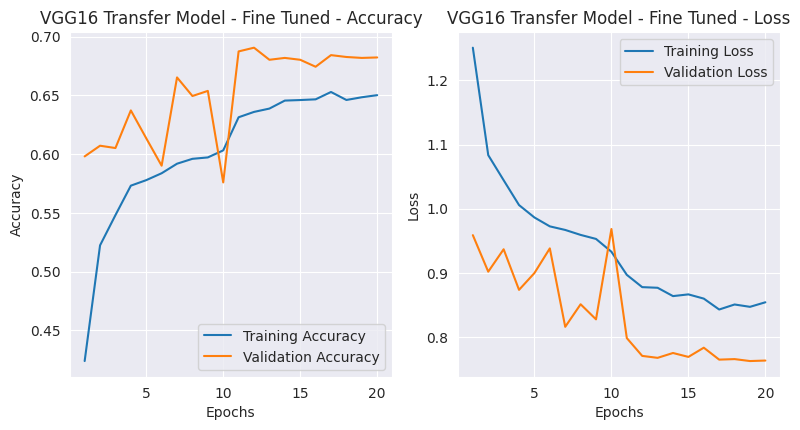


VGG16 Transfer Model - Fine Tuned - Test Results Summary
Test Loss:     0.5168
Test Accuracy: 0.8013 (80.13%)

Training Metrics:
  Final Training Accuracy:   0.6501
  Final Validation Accuracy: 0.6822
  Final Training Loss:       0.8541
  Final Validation Loss:     0.7633

79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step
Classification Report
               precision    recall  f1-score   support

           0       0.88      0.88      0.88       729
           1       0.71      0.74      0.72       654
           2       0.74      0.72      0.73       644
           3       0.89      0.89      0.89       500

    accuracy                           0.80      2527
   macro avg       0.80      0.80      0.80      2527
weighted avg       0.80      0.80      0.80      2527



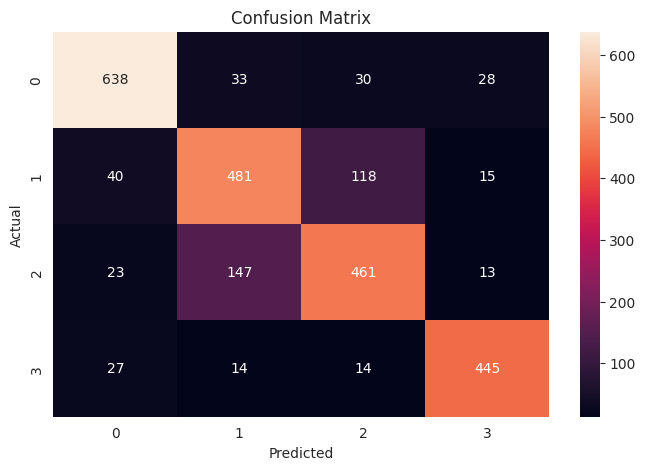

In [33]:
df_results = evaluate_predict_and_report(df_results, test_dataset=test_dataset_224_rgb, model_instance=vgg16_model_instance, history=vgg16_model_history, model_name="VGG16 Transfer Model - Fine Tuned")

Observations:
+ F1 increased from 70% to 80%, a 12.5% improvement!
+ Conviction is still mixed, with confusion between classes (specifically 1 and 2)
+ Given this, it might be good to investigate the datasets for these classes and address any color channel issues (blurriness, brightness)

## **ResNet V2 Model**

In [34]:
def create_resnet2_model(n_classes, learning_rate=0.001, fine_tune=False, optimizer='rmsprop'):
    """
    Compiles a model using vgg16 as a base, with the option of fine_tuning the existing layers

    input_shape: tuple - the shape of input images (width, height, channels)
    n_classes: int - The number of classes to categorize, shapes the softmax output layer
    optimizer: string - instantiated optimizer to use for training. Defaults to 'RMSProp'
    fine_tune: int - The number of pre-trained layers to unfreeze.
                If set to 0, all pretrained layers will freeze during training
    """

    # Include the base, without its top.  We'll provide an alternative
    conv_base = ap.ResNet50V2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    # Defines how many layers to freeze during training.
    # Layers in the convolutional base are switched from trainable to non-trainable
    # depending on the size of the fine-tuning parameter.
    if fine_tune:
        for layer in conv_base.layers:
            if "conv" in layer.name:
                layer.trainable = True
            else:
                layer.trainable = False
    else:
        for layer in conv_base.layers:
            layer.trainable = False

    # Create a simple model for extension:
    top_model = conv_base.output
    top_model = Flatten(name="flatten")(top_model)
    top_model = Dense(256, activation='relu')(top_model)
    top_model = Dropout(0.3)(top_model)
    top_model = Dense(64, activation='relu')(top_model)
    top_model = BatchNormalization()(top_model)
    output_layer = Dense(n_classes, activation='softmax')(top_model)

    # Group the convolutional base and new fully-connected layers into a Model object.
    model = Model(inputs=conv_base.input, outputs=output_layer)

    # Handle optimizer with learning rate
    if isinstance(optimizer, str):
        if optimizer.lower() == 'adam':
            optimizer = Adam(learning_rate=learning_rate)
        elif optimizer.lower() == 'rmsprop':
            optimizer = optimizers.RMSprop(learning_rate=learning_rate)
        elif optimizer.lower() == 'sgd':
            optimizer = optimizers.SGD(learning_rate=learning_rate)

        # Add more optimizers as needed
    # Compiles the model for training.
    model.compile(optimizer=optimizer,
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    return model

### **Model Building**

- Import Resnet v2 upto the layer of your choice and add Fully Connected layers on top of it.

In [35]:
# First clear up the back-end
backend.clear_session()
set_seeds(4565)
resnet2_model_instance = create_resnet2_model(4, 0.01, True)
resnet2_model_history = summarize_and_fit(resnet2_model_instance, "Resnet2", train_dataset_224_rgb, val_dataset_224_rgb)

Model: "functional_36"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_4[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_conv[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_preac… │ (None, 56, 56,    │        256 │ pool1_pool[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_preac… │ (None, 56, 56,    │          0 │ conv2_block1_pre… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,096 │ conv2_block1_pre… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_pad  │ (None, 58, 58,    │          0 │ conv2_block1_1_r… │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_2_p… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_pre… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_out    │ (None, 56, 56,    │          0 │ conv2_block1_0_c

 Total params: 49,272,132 (187.96 MB)

 Trainable params: 49,222,468 (187.77 MB)

 Non-trainable params: 49,664 (194.00 KB)

Epoch 1/20


2025-10-14 23:10:05.478052: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-10-14 23:10:05.989761: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_12819', 24 bytes spill stores, 24 bytes spill loads

2025-10-14 23:10:06.209243: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_12819', 520 bytes spill stores, 520 bytes spill loads

2025-10-14 23:10:10.800574: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng57{k2=1,k13=0,k14=3,k18=1,k23=0} for conv (f32[64,64,3,3]{3,2,1,0}, u8[0]{0}) custom-ca

473/474 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.2793 - loss: 1.4561

2025-10-14 23:10:49.199403: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_12817', 4 bytes spill stores, 4 bytes spill loads



474/474 ━━━━━━━━━━━━━━━━━━━━ 88s 108ms/step - accuracy: 0.2846 - loss: 1.4142 - val_accuracy: 0.3040 - val_loss: 1.4385 - learning_rate: 0.0100
Epoch 2/20
474/474 ━━━━━━━━━━━━━━━━━━━━ 25s 51ms/step - accuracy: 0.2921 - loss: 1.3702 - val_accuracy: 0.3016 - val_loss: 1.5831 - learning_rate: 0.0100
Epoch 3/20
474/474 ━━━━━━━━━━━━━━━━━━━━ 23s 48ms/step - accuracy: 0.3155 - loss: 1.3550 - val_accuracy: 0.2893 - val_loss: 1.3457 - learning_rate: 0.0100
Epoch 4/20
474/474 ━━━━━━━━━━━━━━━━━━━━ 24s 51ms/step - accuracy: 0.3268 - loss: 1.3402 - val_accuracy: 0.2585 - val_loss: 1.8107 - learning_rate: 0.0100
Epoch 5/20
474/474 ━━━━━━━━━━━━━━━━━━━━ 21s 44ms/step - accuracy: 0.3539 - loss: 1.3110 - val_accuracy: 0.2494 - val_loss: 1.4023 - learning_rate: 0.0100
Epoch 6/20
474/474 ━━━━━━━━━━━━━━━━━━━━ 22s 47ms/step - accuracy: 0.3920 - loss: 1.2662 - val_accuracy: 0.4059 - val_loss: 1.2444 - learning_rate: 0.0100
Epoch 7/20
474/474 ━━━━━━━━━━━━━━━━━━━━ 21s 44ms/step - accuracy: 0.4238 - loss: 1.230

#### Observations:
+ Initial performance was poor, with less than a 30% accuracy rate.
+ To improve, the entire model was set for fine-tuning, and the learning rate was tripled.
+ ResNet has far more layers than VGG, and a wider variety of layers
    + Padding Layers
        + Pad the outside of the 2D array to process with zeroes.
        + Allows edge pixels to be processed more accurately
    + Add Layers
        + Allows it to learn hierarchical representations
        + Builds from simple features in early layers to more complex and abstract ones in deeper layers.
        + Allows the network to learn more complex, abstract patterns
    + No real repeating structure of "micro kernels", ie 2 Conv2D layers followed by a pooling layer in repeating fashion.
    + Add layers, however, are occurring once every 11 layers.
        + The structure of each larger Add block varies
    + Add is always followed by Batch Normalization
+ Batch Normalization is always followed by Activation
+ Dropout is not used anywhere in the model, suggesting that the model may be subject to overfitting for fine-tuning efforts.
+ Initial runs training the model hit its best score in the 8th epoch, suggesting that the learning rate was too high.  A lower rate was selected for training

#### Evaluate and Report

79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 56ms/step - accuracy: 0.7087 - loss: 0.6945

FINAL TRAINING STATISTICS

Total Epochs Completed: 20

Metric                    Training        Validation     
------------------------------------------------------------
Loss                      0.7761          0.6798         
Accuracy                  0.6815          0.7190         


Overfitting Gap (Train - Val Accuracy): -0.0374
✓ Model appears to generalize well

Best Validation Accuracy: 0.7190 at epoch 20


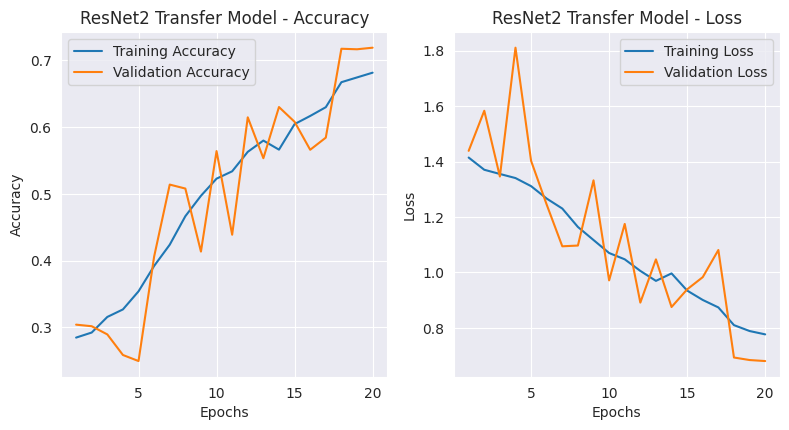


ResNet2 Transfer Model - Test Results Summary
Test Loss:     0.6945
Test Accuracy: 0.7087 (70.87%)

Training Metrics:
  Final Training Accuracy:   0.6815
  Final Validation Accuracy: 0.7190
  Final Training Loss:       0.7761
  Final Validation Loss:     0.6798

79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step
Classification Report
               precision    recall  f1-score   support

           0       0.77      0.80      0.79       729
           1       0.64      0.54      0.59       654
           2       0.60      0.69      0.65       644
           3       0.84      0.82      0.83       500

    accuracy                           0.71      2527
   macro avg       0.72      0.71      0.71      2527
weighted avg       0.71      0.71      0.71      2527



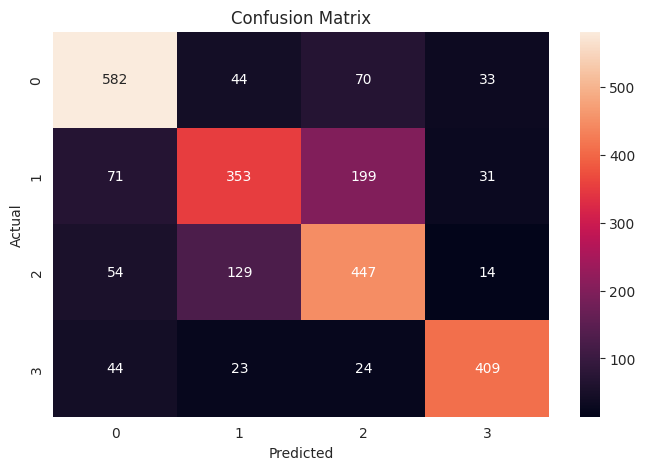

In [36]:
df_results = evaluate_predict_and_report(df_results, test_dataset=test_dataset_224_rgb, model_instance=resnet2_model_instance, history=resnet2_model_history, model_name="ResNet2 Transfer Model")

#### Observations and Insights:
+ ResNet also provided a high F1 score, at 71%.
+ It suffered higher uncertainty with some elements in conviction with some classes
+ The best epoch was 4, indicating that perhaps the learning rate was too high
+ More evaluation on this model is necessary

Can we do better?  Let's fine tune.

In [37]:
fine_tune_model(resnet2_model_instance, train_dataset_224_rgb, val_dataset_224_rgb, "resnet2_tuned", 25)

Epoch 1/20
474/474 ━━━━━━━━━━━━━━━━━━━━ 97s 109ms/step - accuracy: 0.6658 - loss: 0.8033 - val_accuracy: 0.6103 - val_loss: 1.1243 - learning_rate: 5.0000e-05
Epoch 2/20
474/474 ━━━━━━━━━━━━━━━━━━━━ 24s 50ms/step - accuracy: 0.6804 - loss: 0.7716 - val_accuracy: 0.7265 - val_loss: 0.6840 - learning_rate: 5.0000e-05
Epoch 3/20
474/474 ━━━━━━━━━━━━━━━━━━━━ 24s 50ms/step - accuracy: 0.6883 - loss: 0.7539 - val_accuracy: 0.7241 - val_loss: 0.6678 - learning_rate: 5.0000e-05
Epoch 4/20
474/474 ━━━━━━━━━━━━━━━━━━━━ 22s 47ms/step - accuracy: 0.6945 - loss: 0.7504 - val_accuracy: 0.7308 - val_loss: 0.6660 - learning_rate: 5.0000e-05
Epoch 5/20
474/474 ━━━━━━━━━━━━━━━━━━━━ 24s 50ms/step - accuracy: 0.6945 - loss: 0.7460 - val_accuracy: 0.7320 - val_loss: 0.6647 - learning_rate: 5.0000e-05
Epoch 6/20
474/474 ━━━━━━━━━━━━━━━━━━━━ 24s 50ms/step - accuracy: 0.6967 - loss: 0.7435 - val_accuracy: 0.7356 - val_loss: 0.6622 - learning_rate: 5.0000e-05
Epoch 7/20
474/474 ━━━━━━━━━━━━━━━━━━━━ 22s 46ms/st

#### Evaluate the model

79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 65ms/step - accuracy: 0.7178 - loss: 0.6781

FINAL TRAINING STATISTICS

Total Epochs Completed: 20

Metric                    Training        Validation     
------------------------------------------------------------
Loss                      0.7761          0.6798         
Accuracy                  0.6815          0.7190         


Overfitting Gap (Train - Val Accuracy): -0.0374
✓ Model appears to generalize well

Best Validation Accuracy: 0.7190 at epoch 20


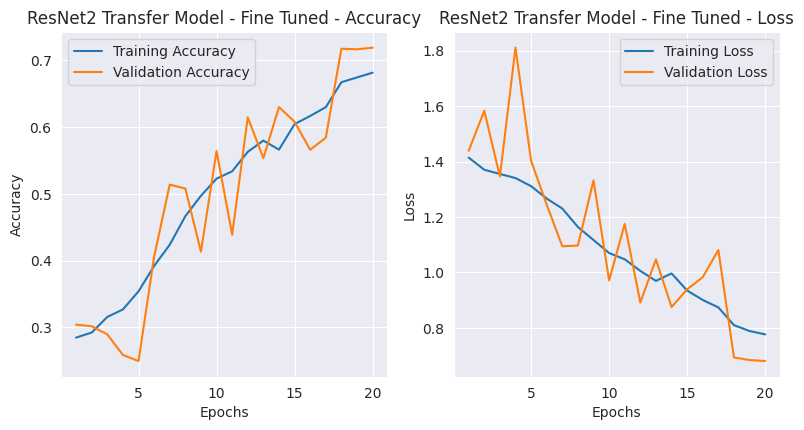


ResNet2 Transfer Model - Fine Tuned - Test Results Summary
Test Loss:     0.6781
Test Accuracy: 0.7178 (71.78%)

Training Metrics:
  Final Training Accuracy:   0.6815
  Final Validation Accuracy: 0.7190
  Final Training Loss:       0.7761
  Final Validation Loss:     0.6798

79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step
Classification Report
               precision    recall  f1-score   support

           0       0.81      0.80      0.81       729
           1       0.61      0.61      0.61       654
           2       0.63      0.65      0.64       644
           3       0.84      0.82      0.83       500

    accuracy                           0.72      2527
   macro avg       0.72      0.72      0.72      2527
weighted avg       0.72      0.72      0.72      2527



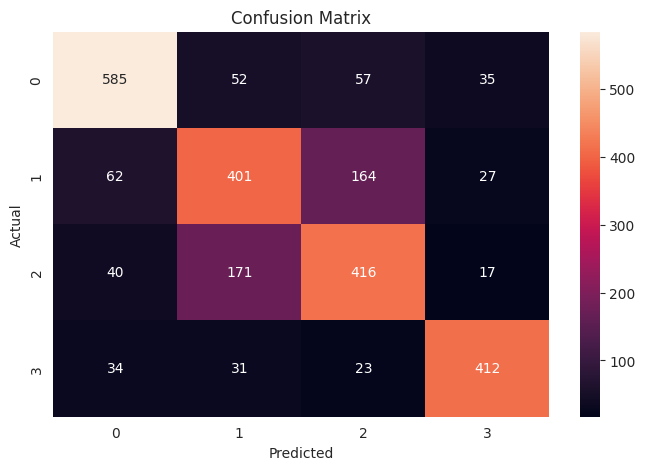

In [38]:
df_results = evaluate_predict_and_report(df_results, test_dataset=test_dataset_224_rgb, model_instance=resnet2_model_instance, history=resnet2_model_history, model_name="ResNet2 Transfer Model - Fine Tuned")

## **EfficientNet Model**

In [39]:
def create_efficient_net_model(n_classes, learning_rate=0.001, optimizer="rmsprop"):
    # Include the base, without its top.  We'll provide an alternative
    conv_base = ap.EfficientNetV2B0(include_top=False, input_shape=(224, 224, 3))
    conv_base.trainable = False

    # Create a simple model for extension:
    top_model = conv_base.output
    top_model = BatchNormalization()(top_model)
    top_model = Flatten(name="flatten")(top_model)
    top_model = Dense(256, activation='relu')(top_model)
    top_model = LeakyReLU(negative_slope=0.1)(top_model)
    top_model = Dropout(0.3)(top_model)
    top_model = Dense(64, activation='relu')(top_model)
    top_model = LeakyReLU(negative_slope=0.1)(top_model)
    output_layer = Dense(n_classes, activation='softmax')(top_model)

    # Group the convolutional base and new fully-connected layers into a Model object.
    model = Model(inputs=conv_base.input, outputs=output_layer)

    # Handle optimizer with learning rate
    if isinstance(optimizer, str):
        if optimizer.lower() == 'adam':
            optimizer = Adam(learning_rate=learning_rate)
        elif optimizer.lower() == 'rmsprop':
            optimizer = optimizers.RMSprop(learning_rate=learning_rate)
        elif optimizer.lower() == 'sgd':
            optimizer = optimizers.SGD(learning_rate=learning_rate)
        # Add more optimizers as needed

    # Compiles the model for training.
    model.compile(optimizer=optimizer,
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    return model

#### Create the model, then summarize and fit

In [40]:
# First clear up the back-end
backend.clear_session()
set_seeds(1243)
efficient_model_instance = create_efficient_net_model(4, 0.001)
efficient_model_history = summarize_and_fit(efficient_model_instance, "EfficientNetB0", train_dataset_224_rgb, val_dataset_224_rgb)

Model: "functional_37"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer_5[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          0 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ normalization[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │      4,608 │ stem_activation[… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_bn  │ (None, 112, 112,  │         64 │ block1a_project_… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_ac… │ (None, 112, 112,  │          0 │ block1a_project_… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_conv │ (None, 56, 56,    │      9,216 │ block1a_project_… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_bn   │ (None, 56, 56,    │        256 │ block2a_expand_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_act… │ (None, 56, 56,    │          0 │ block2a_expand_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_project_co… │ (None, 56, 56,    │      2,048 │ block2a_expand_a… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_project_bn  │ (None, 56, 56,    │        128 │ block2a_project_… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_conv │ (None, 56, 56,    │     36,864 │ block2a_project_… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_bn   │ (None, 56, 56,    │        512 │ block2b_expand_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_act… │ (None, 56, 56,    │          0 │ block2b_expand_b

 Total params: 21,997,716 (83.91 MB)

 Trainable params: 16,075,844 (61.32 MB)

 Non-trainable params: 5,921,872 (22.59 MB)

...

471/474 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.2643 - loss: 9.9861 

2025-10-14 23:26:52.268684: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_12051', 4 bytes spill stores, 4 bytes spill loads

2025-10-14 23:26:56.566631: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-10-14 23:26:56.729027: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-10-14 23:26:56.902323: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-10-14 23:26:57.076576: E external/local_xla/xla/str

474/474 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.2643 - loss: 9.9454

2025-10-14 23:27:20.174649: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2388', 4 bytes spill stores, 4 bytes spill loads

2025-10-14 23:27:24.204777: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-10-14 23:27:24.355257: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-10-14 23:27:25.540548: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-10-14 23:27:25.802292: E external/local_xla/xla/stre

474/474 ━━━━━━━━━━━━━━━━━━━━ 81s 109ms/step - accuracy: 0.2693 - loss: 3.5519 - val_accuracy: 0.2885 - val_loss: 1.3784 - learning_rate: 0.0010
Epoch 2/20
474/474 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - accuracy: 0.2884 - loss: 1.3850 - val_accuracy: 0.2885 - val_loss: 1.3776 - learning_rate: 0.0010
Epoch 3/20
474/474 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.2883 - loss: 1.3807 - val_accuracy: 0.2885 - val_loss: 1.3775 - learning_rate: 0.0010
Epoch 4/20
474/474 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - accuracy: 0.2884 - loss: 1.3798 - val_accuracy: 0.2885 - val_loss: 1.3775 - learning_rate: 0.0010
Epoch 5/20
474/474 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step - accuracy: 0.2885 - loss: 1.3776 - val_accuracy: 0.2885 - val_loss: 1.3775 - learning_rate: 0.0010
Epoch 6/20
473/474 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.2901 - loss: 1.3769
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
474/474 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.2886 - loss: 1.3777

#### Observations:
+ Efficient has a much larger model that VGG or ResNet.
+ The network employs some new layer types:
    + Multiply
        + Used after Conv2D layers, used to intensify the transformation
    + Reshape
        + Reshape the output at a given layer for the layers to come, enables a dramatic change in resolution
    + Rescale
        + Rescales the image processed
    + Depthwise Conv2D
        + Applies a separate filter to each individual input channel. If the input has N channels, N distinct filters are used, one for each channel. Each filter convolves only with its corresponding input channel, producing a single output channel for that input channel. These individual output channels are then concatenated along the channel axis.
    + GlobalAveragePool
        + A pooling technique used in CNNs that significantly reduces the spatial dimensions of feature maps.
#### **Evaluating the EfficientNet Model**

75/79 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.2887 - loss: 1.3782

2025-10-14 23:31:02.847086: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-10-14 23:31:07.624585: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-10-14 23:31:07.773423: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-10-14 23:31:07.935013: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please invest

79/79 ━━━━━━━━━━━━━━━━━━━━ 12s 159ms/step - accuracy: 0.2885 - loss: 1.3774

FINAL TRAINING STATISTICS

Total Epochs Completed: 20

Metric                    Training        Validation     
------------------------------------------------------------
Loss                      1.3774          1.3775         
Accuracy                  0.2886          0.2885         


Overfitting Gap (Train - Val Accuracy): 0.0000
✓ Model appears to generalize well

Best Validation Accuracy: 0.2885 at epoch 1


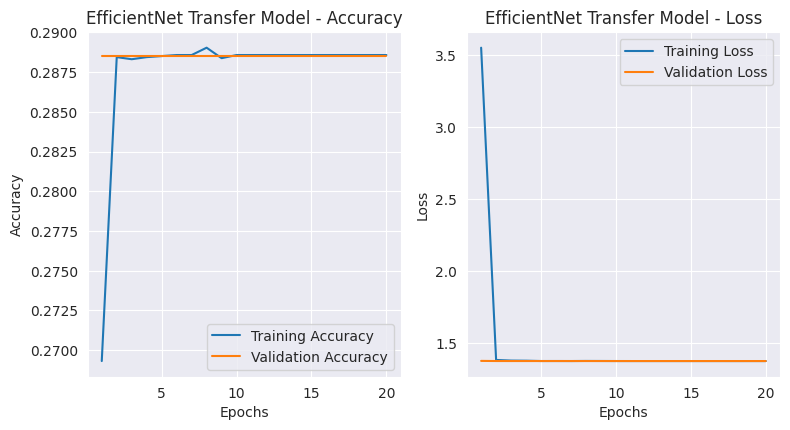


EfficientNet Transfer Model - Test Results Summary
Test Loss:     1.3774
Test Accuracy: 0.2885 (28.85%)

Training Metrics:
  Final Training Accuracy:   0.2886
  Final Validation Accuracy: 0.2885
  Final Training Loss:       1.3774
  Final Validation Loss:     1.3775

79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step
Classification Report
               precision    recall  f1-score   support

           0       0.29      1.00      0.45       729
           1       0.00      0.00      0.00       654
           2       0.00      0.00      0.00       644
           3       0.00      0.00      0.00       500

    accuracy                           0.29      2527
   macro avg       0.07      0.25      0.11      2527
weighted avg       0.08      0.29      0.13      2527



2025-10-14 23:31:30.708179: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
/home/julian/my_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/julian/my_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/julian/my_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted

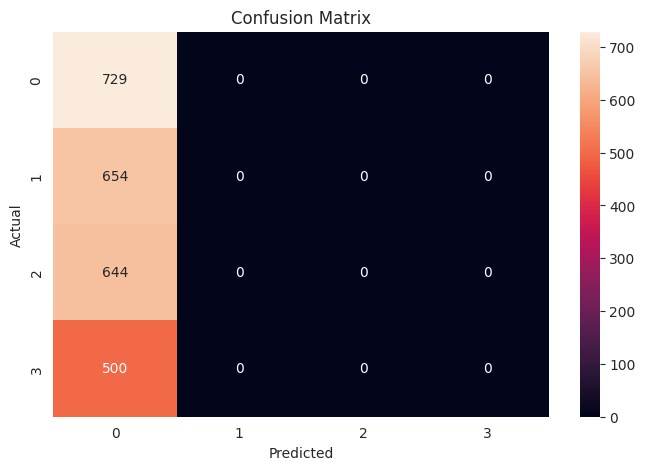

In [41]:
df_results = evaluate_predict_and_report(df_results, test_dataset=test_dataset_224_rgb, model_instance=efficient_model_instance, history=efficient_model_history, model_name="EfficientNet Transfer Model")


### Observations and Insights
The EfficientNet model did not work well.  This may be due to a variety of causes:
+ Incorrect configuration, or transfer learning strategies
+ The model state after training is not configured to detect the types of features necessary to categorize expressions.

Due to its low initial score, it's not a good candidate for further tuning.  We'll move on to the next model.

**Think About It:**

* What is your overall performance of these Transfer Learning Architectures? Can we draw a comparison of these models' performances. Are we satisfied with the accuracies that we have received?

No, we're not satisfied with the accuracy so far.  We can do better.

* Do you think our issue lies with 'rgb' color_mode?

No.  The initial comparison between RGB and grayscale processing showed that there was little difference.

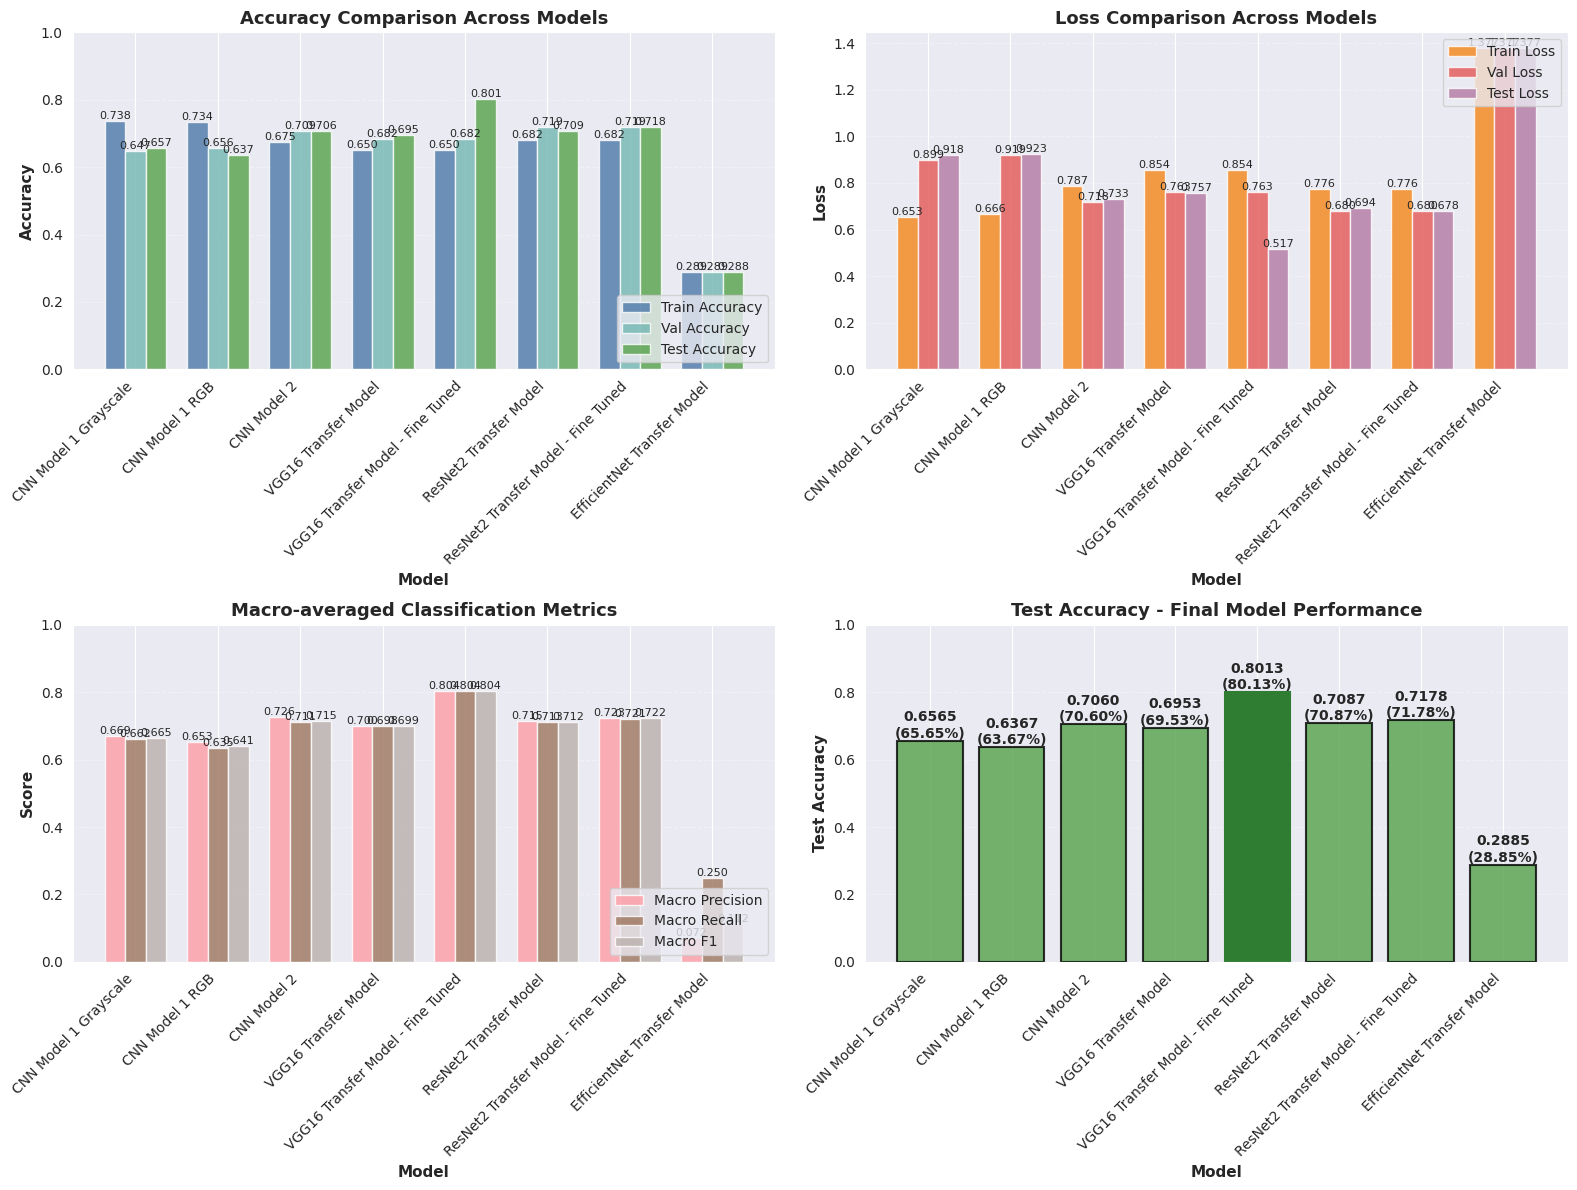


MODEL COMPARISON SUMMARY
                               name epochs  train_loss  train_accuracy  val_loss  val_accuracy  test_loss  test_accuracy  macro_precision  macro_recall  macro_f1
              CNN Model 1 Grayscale     15    0.652835        0.737877  0.898768      0.647036   0.918366       0.656510         0.669471      0.661706  0.664836
                    CNN Model 1 RGB     15    0.666003        0.733588  0.918800      0.655731   0.923138       0.636723         0.653318      0.634651  0.641362
                        CNN Model 2     15    0.786502        0.674606  0.717639      0.708696   0.732958       0.705975         0.725996      0.710697  0.715488
               VGG16 Transfer Model     20    0.854132        0.650129  0.763327      0.682213   0.757157       0.695291         0.700115      0.698398  0.699006
  VGG16 Transfer Model - Fine Tuned     20    0.854132        0.650129  0.763327      0.682213   0.516758       0.801345         0.804289      0.804121  0.804110
  

In [42]:
plot_model_comparison(df_results)

Observations:
+ VGG16 was the highest performing model
+ Second was the ResNet2 Transfer Model
+ Let's use elements of these two architectures for our next model

## **Building a Complex Neural Network Architecture**

In this section, we will build a more complex Convolutional Neural Network Model that has close to as many parameters as we had in our Transfer Learning Models. However, we will have only 1 input channel for our input images.  Here is the dataset for the tests:

In [43]:
train_dataset_224_gs, val_dataset_224_gs, test_dataset_224_gs = prepare_datasets(
    train_dataset_base, val_dataset_base, test_dataset_base,
    color_mode='grayscale',
    batch_size=batch_size,
    img_size=224
)

### Third Model Architecture
+ We'll add five convolutional layers
+ Each layer will have leakyReLU
+ Two pairs of Conv2D will be followed by a max pooling layer
+ Batch normalization will following the pooling
+ A final Conv2d layer will then lead into a pooling layer
+ From there, a flattening and two dense layers culminating in a softmax layer

In [44]:
def cnn_model_3(input_channels=3):
    """
    Build a CNN model with deeper architecture for improved performance.

    Args:
        input_channels: Number of input channels (1 for grayscale, 3 for RGB)
    """
    model = Sequential()
    # Input shape = (48, 48, input_channels)
    model.add(Input(shape=(224, 224, input_channels)))
    # First Convolutional layer with 16 filters, kernel size 5x5, same padding
    model.add(Conv2D(16, kernel_size=(3, 3), padding='same'))
    # LeakyReLU activation with slope 0.1
    model.add(LeakyReLU(negative_slope=0.1))
    # Second Convolutional layer with 32 filters, kernel size 3x3, same padding
    model.add(Conv2D(32, kernel_size=(5, 5), padding='same'))
    # LeakyReLU activation with slope 0.1
    model.add(LeakyReLU(negative_slope=0.1))
    # Max pooling layer with pool size 2x2
    model.add(MaxPooling2D(pool_size=(5, 5)))
    # BatchNormalization layer
    model.add(BatchNormalization())
    # Third Convolutional layer with 32 filters, kernel size 3x3, same padding
    model.add(Conv2D(32, kernel_size=(7, 7), padding='same'))
    # LeakyReLU activation with slope 0.1
    model.add(LeakyReLU(negative_slope=0.1))
    # Fourth Convolutional layer with 64 filters, kernel size 3x3, same padding
    model.add(Conv2D(64, kernel_size=(7, 7), padding='same'))
    # LeakyReLU activation with slope 0.1
    model.add(LeakyReLU(negative_slope=0.1))
    # Max pooling layer with pool size 2x2
    model.add(MaxPooling2D(pool_size=(5, 5)))
    # BatchNormalization layer
    model.add(BatchNormalization())
    # Flatten the output from previous layer
    model.add(Conv2D(64, kernel_size=(15, 15), padding='same'))
    # LeakyReLU activation with slope 0.1
    model.add(LeakyReLU(negative_slope=0.1))
    # Final pooling
    model.add(MaxPooling2D(pool_size=(5, 5)))
    # Flatten
    model.add(Flatten())
    # Dropout at the head of the flatten layer to zero out portions of the signal
    model.add(Dropout(0.3))
    # Dense layer with 32 nodes
    model.add(Dense(64))
    # LeakyReLU activation with slope 0.1
    model.add(LeakyReLU(negative_slope=0.1))
    # Dropout layer with rate 0.5
    model.add(Dense(32))
    model.add(LeakyReLU(negative_slope=0.1))
    # Output layer with 4 nodes (number of classes) and softmax activation
    model.add(Dense(4, activation='softmax'))
    # Compile the model
    model.compile(
        loss='categorical_crossentropy',
        optimizer=Adam(learning_rate=0.001),
        metrics=['accuracy']
    )

    return model

### **Compiling and Training the Model**

In [45]:
backend.clear_session()
set_seeds(1243)
cnn_model_3_instance = cnn_model_3(1)
cnn_model_3_history = summarize_and_fit(cnn_model_3_instance, "CNN Model 3", train_dataset_224_gs, val_dataset_224_gs)

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 224, 224, 16)   │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_13 (LeakyReLU)      │ (None, 224, 224, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 224, 224, 32)   │        12,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_14 (LeakyReLU)      │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 44, 44, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 44, 44, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 44, 44, 32)     │        50,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_15 (LeakyReLU)      │ (None, 44, 44, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 44, 44, 64)     │       100,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_16 (LeakyReLU)      │ (None, 44, 44, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 8, 8, 64)       │       921,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_17 (LeakyReLU)      │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 1, 1, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_18 (LeakyReLU)      │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_19 (LeakyReLU)      │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,092,036 (4.17 MB)

 Trainable params: 1,091,844 (4.17 MB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/20
474/474 ━━━━━━━━━━━━━━━━━━━━ 25s 36ms/step - accuracy: 0.2815 - loss: 1.4530 - val_accuracy: 0.3024 - val_loss: 1.3714 - learning_rate: 0.0010
Epoch 2/20
474/474 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - accuracy: 0.3245 - loss: 1.3537 - val_accuracy: 0.3791 - val_loss: 1.2759 - learning_rate: 0.0010
Epoch 3/20
474/474 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.4116 - loss: 1.2533 - val_accuracy: 0.4949 - val_loss: 1.0925 - learning_rate: 0.0010
Epoch 4/20
474/474 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.4969 - loss: 1.1229 - val_accuracy: 0.5901 - val_loss: 0.9596 - learning_rate: 0.0010
Epoch 5/20
474/474 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.5647 - loss: 1.0092 - val_accuracy: 0.5996 - val_loss: 0.9514 - learning_rate: 0.0010
Epoch 6/20
474/474 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - accuracy: 0.6028 - loss: 0.9336 - val_accuracy: 0.6514 - val_loss: 0.8215 - learning_rate: 0.0010
Epoch 7/20
474/474 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.6236 - los

### **Evaluating the Model on Test Set**

79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.7361 - loss: 0.6490

FINAL TRAINING STATISTICS

Total Epochs Completed: 20

Metric                    Training        Validation     
------------------------------------------------------------
Loss                      0.5974          0.6601         
Accuracy                  0.7646          0.7391         


Overfitting Gap (Train - Val Accuracy): 0.0255
✓ Model appears to generalize well

Best Validation Accuracy: 0.7403 at epoch 18


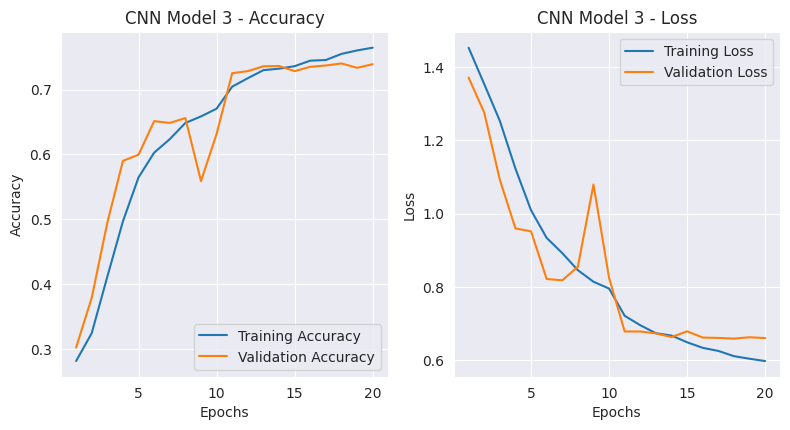


CNN Model 3 - Test Results Summary
Test Loss:     0.6490
Test Accuracy: 0.7361 (73.61%)

Training Metrics:
  Final Training Accuracy:   0.7646
  Final Validation Accuracy: 0.7391
  Final Training Loss:       0.5974
  Final Validation Loss:     0.6601

79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
Classification Report
               precision    recall  f1-score   support

           0       0.81      0.82      0.82       729
           1       0.64      0.69      0.66       654
           2       0.66      0.62      0.64       644
           3       0.85      0.82      0.84       500

    accuracy                           0.74      2527
   macro avg       0.74      0.74      0.74      2527
weighted avg       0.74      0.74      0.74      2527



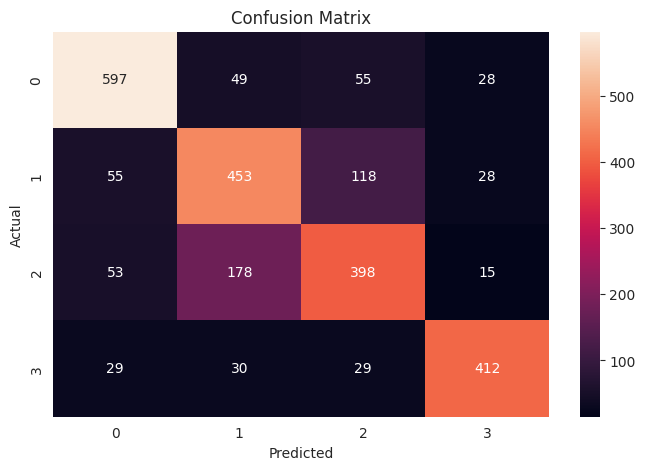

In [46]:
df_results = evaluate_predict_and_report(df_results, test_dataset=test_dataset_224_gs, model_instance=cnn_model_3_instance, history=cnn_model_3_history, model_name="CNN Model 3")

#### Observations and Insights:
+ We have achieved a close F1 score to VGG16.
+ We're still not there, yet
+ However, this model is much smaller than VGG16.
+ Additional tuning should result in higher accuracy scores.

## Conclusion:

### **Insights**

### **Refined insights**:
+ There are some trends in model architecture construction that will require further review
  + The flow from Conv2D -> Relu activation -> Pooling -> Batch Normalization
  + The size of the filters and pooling layers
  + The structure of the dense layer classifiers needs further experimentation

### **Comparison of various techniques and their relative performance**:
- How do different techniques perform? Which one is performing relatively better? Is there scope to improve the performance further?

Let's take a look at the final report:

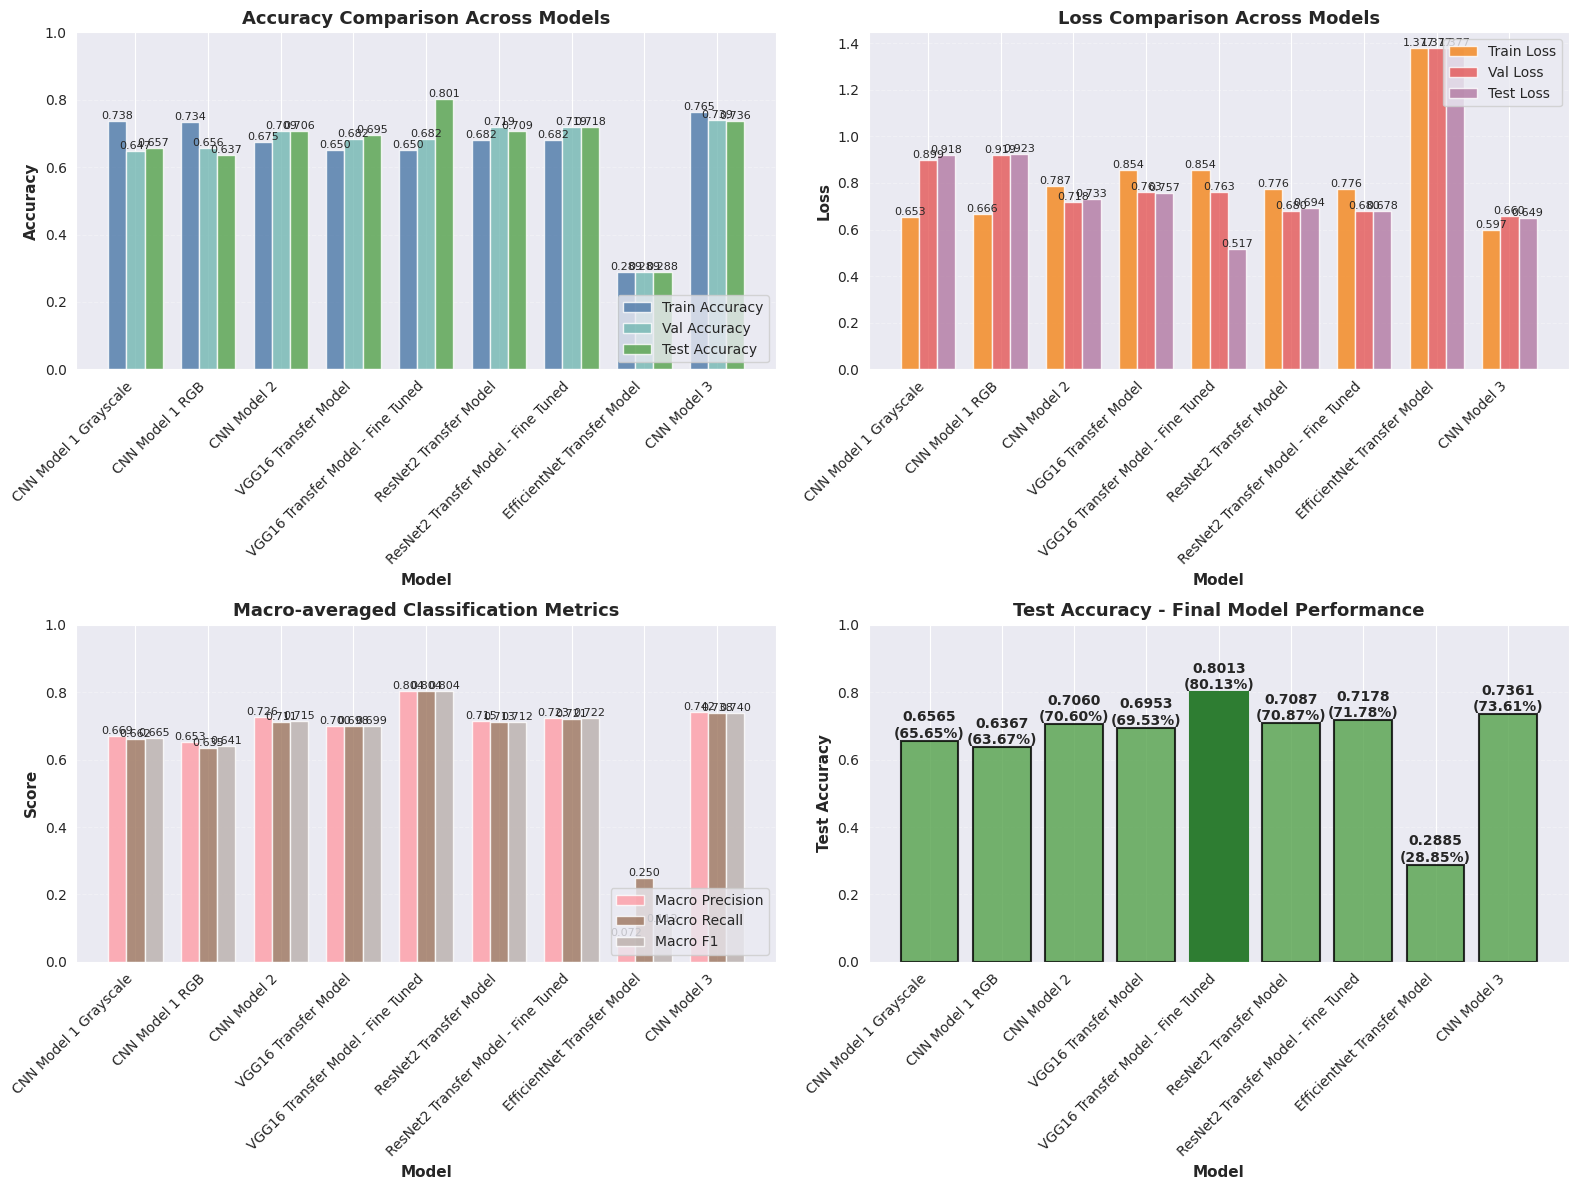


MODEL COMPARISON SUMMARY
                               name epochs  train_loss  train_accuracy  val_loss  val_accuracy  test_loss  test_accuracy  macro_precision  macro_recall  macro_f1
              CNN Model 1 Grayscale     15    0.652835        0.737877  0.898768      0.647036   0.918366       0.656510         0.669471      0.661706  0.664836
                    CNN Model 1 RGB     15    0.666003        0.733588  0.918800      0.655731   0.923138       0.636723         0.653318      0.634651  0.641362
                        CNN Model 2     15    0.786502        0.674606  0.717639      0.708696   0.732958       0.705975         0.725996      0.710697  0.715488
               VGG16 Transfer Model     20    0.854132        0.650129  0.763327      0.682213   0.757157       0.695291         0.700115      0.698398  0.699006
  VGG16 Transfer Model - Fine Tuned     20    0.854132        0.650129  0.763327      0.682213   0.516758       0.801345         0.804289      0.804121  0.804110
  

In [47]:
plot_model_comparison(df_results)



### **Proposal for the final solution design**:
- What model do you propose to be adopted? Why is this the best solution to adopt?

The transfer learning models clearly outperformed any of the CNN models I have created.

Based on current performance, the VGG16 Transfer Model will be the best solution to adopt.  But work will also continue on CNN Model 3.  If a smaller model can provide equal results, it will be cheaper to train and run, and could operate in a wider range of hardware profiles.

We can possibly improve on CNN Model 3 with the following:
+ Experiment with different model architectures
    + Introducing Add layers for hierarchical pattern processing
    + Adding more convolution layers
    + Varying the filter sizes
+ Varying the datasets
    + Reshuffling the datasets over smaller training runs
    + Altering the batch sizes
    + Introducing additional datasets
    + Digitally processing the images where brightness or sharpness is an issue
    + Experimenting with different learning rates
    + Experimenting with different optimizers